# 3. Linear Neural Networks for Regression

Before we worry about making our neural networks deep, it will be helpful to implement some shallow ones, for which the inputs connect directly to the outputs. This will prove important for a few reasons. First, rather than getting distracted by complicated architectures, we can focus on the basics of neural network training, including parametrizing the output layer, handling data, specifying a loss function, and training the model. Second, this class of shallow networks happens to comprise the set of linear models, which subsumes many classical methods of statistical prediction, including linear and softmax regression. Understanding these classical tools is pivotal because they are widely used in many contexts and we will often need to use them as baselines when justifying the use of fancier architectures. This chapter will focus narrowly on linear regression and the next one will extend our modeling repertoire by developing linear neural networks for classification.

## 3.1. Linear Regression

*Regression* problems pop up whenever we want to predict a numerical value. Common examples include predicting prices (of homes, stocks, etc.), predicting the length of stay (for patients in the hospital), forecasting demand (for retail sales), among numerous others. Not every prediction problem is one of classical regression. Later on, we will introduce classification problems, where the goal is to predict membership among a set of categories.

As a running example, suppose that we wish to estimate the prices of houses (in dollars) based on their area (in square feet) and age (in years). To develop a model for predicting house prices, we need to get our hands on data, including the sales price, area, and age for each home. In the terminology of machine learning, the dataset is called a *training dataset* or *training set*, and each row (containing the data corresponding to one sale) is called an *example* (or *data point*, *instance*, *sample*). The thing we are trying to predict (price) is called a *label* (or *target*). The variables (age and area) upon which the predictions are based are called *features* (or *covariates*).

In [ ]:
%matplotlib inline
import math
import time
import numpy as np
import torch
from d2l import torch as d2l

### 3.1.1. Basics

*Linear regression* is both the simplest and most popular among the standard tools for tackling regression problems. Dating back to the dawn of the 19th century (Gauss, 1809, Legendre, 1805), linear regression flows from a few simple assumptions. First, we assume that the relationship between features $\mathbf{x}$ and target $y$ is *approximately linear*, i.e., that the conditional mean $E[Y \mid X=\mathbf{x}]$ can be expressed as a weighted sum of the features $\mathbf{x}$. This setup allows that the target value may still deviate from its expected value on account of observation noise. Next, we can impose the assumption that any such noise is *well behaved*, following a Gaussian distribution. Typically, we will use $n$ to denote the number of examples in our dataset. We use superscripts to enumerate samples and targets, and subscripts to index coordinates. More concretely, $\mathbf{x}^{(i)}$ denotes the $i^{\textrm{th}}$ sample and $x_j^{(i)}$ denotes its $j^{\textrm{th}}$ coordinate.

#### 3.1.1.1. Model

...

Collecting all features into a vector $\mathbf{x} \in \mathbb{R}^d$ and all weights into a vector $\mathbf{w} \in \mathbb{R}^d$, we can express our model compactly via the dot product between $\mathbf{w}$ and $\mathbf{x}$:

$$\hat{y} = \mathbf{w}^\top \mathbf{x} + b. \tag{3.1.3}$$

In (3.1.3), the vector $\mathbf{x}$ corresponds to the features of a single example. We will often find it convenient to refer to features of our entire dataset of $n$ examples via the *design matrix* $\mathbf{X} \in \mathbb{R}^{n \times d}$. Here, $\mathbf{X}$ contains one row for every example and one column for every feature. For a collection of features $\mathbf{X}$, the predictions $\hat{\mathbf{y}} \in \mathbb{R}^n$ can be expressed via the matrix--vector product:

$${\hat{\mathbf{y}}} = \mathbf{X} \mathbf{w} + b, \tag{3.1.4}$$

where broadcasting (Section 2.1.4) is applied during the summation. Given features of a training dataset $\mathbf{X}$ and corresponding (known) labels $\mathbf{y}$, the goal of linear regression is to find the weight vector $\mathbf{w}$ and the bias term $b$ such that, given features of a new data example sampled from the same distribution as $\mathbf{X}$, the new example's label will (in expectation) be predicted with the smallest error.

Even if we believe that the best model for predicting $y$ given $\mathbf{x}$ is linear, we would not expect to find a real-world dataset of $n$ examples where $y^{(i)}$ exactly equals $\mathbf{w}^\top \mathbf{x}^{(i)}+b$ for all $1 \leq i \leq n$. For example, whatever instruments we use to observe the features $\mathbf{X}$ and labels $\mathbf{y}$, there might be a small amount of measurement error. Thus, even when we are confident that the underlying relationship is linear, we will incorporate a noise term to account for such errors.

Before we can go about searching for the best *parameters* (or *model parameters*) $\mathbf{w}$ and $b$, we will need two more things: (i) a measure of the quality of some given model; and (ii) a procedure for updating the model to improve its quality.

#### 3.1.1.2. Loss Function

Naturally, fitting our model to the data requires that we agree on some measure of *fitness* (or, equivalently, of *unfitness*). *Loss functions* quantify the distance between the *real* and *predicted* values of the target. The loss will usually be a nonnegative number where smaller values are better and perfect predictions incur a loss of 0. For regression problems, the most common loss function is the squared error. When our prediction for an example $i$ is $\hat{y}^{(i)}$ and the corresponding true label is $y^{(i)}$, the *squared error* is given by:

$$l^{(i)}(\mathbf{w}, b) = \frac{1}{2} \left(\hat{y}^{(i)} - y^{(i)}\right)^2. \tag{3.1.5}$$

The constant $\frac{1}{2}$ makes no real difference but proves to be notationally convenient, since it cancels out when we take the derivative of the loss. Because the training dataset is given to us, and thus is out of our control, the empirical error is only a function of the model parameters. In Fig. 3.1.1, we visualize the fit of a linear regression model in a problem with one-dimensional inputs.

<p align="center">
  <img src="https://d2l.ai/_images/fit-linreg.svg"/>
  <br />
  <em>Fig. 3.1.1</em> Fitting a linear regression model to one-dimensional data.
</p>

Note that large differences between estimates $\hat{y}^{(i)}$ and targets $y^{(i)}$ lead to even larger contributions to the loss, due to its quadratic form (this quadraticity can be a double-edge sword; while it encourages the model to avoid large errors it can also lead to excessive sensitivity to anomalous data). To measure the quality of a model on the entire dataset of $n$ examples, we simply average (or equivalently, sum) the losses on the training set:

$$L(\mathbf{w}, b) =\frac{1}{n}\sum_{i=1}^n l^{(i)}(\mathbf{w}, b) =\frac{1}{n} \sum_{i=1}^n \frac{1}{2}\left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right)^2. \tag{3.1.6}$$

When training the model, we seek parameters ($\mathbf{w}^*, b^*$) that minimize the total loss across all training examples:

$$\mathbf{w}^*, b^* = \operatorname*{argmin}_{\mathbf{w}, b}\  L(\mathbf{w}, b). \tag{3.1.7}$$

#### 3.1.1.3. Analytic Solution

...

#### 3.1.1.4. Minibatch Stochastic Gradient Descent

Fortunately, even in cases where we cannot solve the models analytically, we can still often train models effectively in practice. Moreover, for many tasks, those hard-to-optimize models turn out to be so much better that figuring out how to train them ends up being well worth the trouble.

The key technique for optimizing nearly every deep learning model, and which we will call upon throughout this book, consists of iteratively reducing the error by updating the parameters in the direction that incrementally lowers the loss function. This algorithm is called *gradient descent*.

The most naive application of gradient descent consists of taking the derivative of the loss function, which is an average of the losses computed on every single example in the dataset. In practice, this can be extremely slow: we must pass over the entire dataset before making a single update, even if the update steps might be very powerful (Liu and Nocedal, 1989). Even worse, if there is a lot of redundancy in the training data, the benefit of a full update is limited.

The other extreme is to consider only a single example at a time and to take update steps based on one observation at a time. The resulting algorithm, *stochastic gradient descent* (SGD) can be an effective strategy (Bottou, 2010), even for large datasets. Unfortunately, SGD has drawbacks, both computational and statistical. One problem arises from the fact that processors are a lot faster multiplying and adding numbers than they are at moving data from main memory to *processor cache*. It is up to an order of magnitude more efficient to perform a matrix--vector multiplication than a corresponding number of vector--vector operations. This means that it can take a lot longer to process one sample at a time compared to a full batch. A second problem is that some of the layers, such as *batch normalization* (to be described in Section 8.5), only work well when we have access to more than one observation at a time.

The solution to both problems is to pick an intermediate strategy: rather than taking a full batch or only a single sample at a time, we take a *minibatch* of observations (Li et al., 2014). The specific choice of the size of the said minibatch depends on many factors, such as the amount of memory, the number of accelerators, the choice of layers, and the total dataset size. Despite all that, a number between 32 and 256, preferably a multiple of a large power of $2$, is a good start. This leads us to *minibatch stochastic gradient descent*.

In its most basic form, in each iteration $t$, we first randomly sample a minibatch $\mathcal{B}_t$ consisting of a fixed number $|\mathcal{B}|$ of training examples. We then compute the derivative (gradient) of the average loss on the minibatch with respect to the model parameters. Finally, we multiply the gradient by a predetermined small positive value $\eta$, called the *learning rate*, and subtract the resulting term from the current parameter values. We can express the update as follows:

$$(\mathbf{w},b) \leftarrow (\mathbf{w},b) - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}_t} \partial_{(\mathbf{w},b)} l^{(i)}(\mathbf{w},b). \tag{3.1.10}$$

In summary, minibatch SGD proceeds as follows: (i) initialize the values of the model parameters, typically at random; (ii) iteratively sample random minibatches from the data, updating the parameters in the direction of the negative gradient. For quadratic losses and affine transformations, this has a closed-form expansion:

$$\begin{aligned}
\mathbf{w} & \leftarrow \mathbf{w} - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}_t} \partial_{\mathbf{w}} l^{(i)}(\mathbf{w}, b) && = \mathbf{w} - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}_t} \mathbf{x}^{(i)} \left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right)\\ b &\leftarrow b -  \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}_t} \partial_b l^{(i)}(\mathbf{w}, b) &&  = b - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}_t} \left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right).
\end{aligned} \tag{3.1.11}$$

Since we pick a minibatch $\mathcal{B}$ we need to normalize by its size $|\mathcal{B}|$. Frequently minibatch size and learning rate are user-defined. Such tunable parameters that are not updated in the training loop are called *hyperparameters*. They can be tuned automatically by a number of techniques, such as Bayesian optimization (Frazier, 2018). In the end, the quality of the solution is typically assessed on a separate *validation dataset* (or *validation set*).

After training for some predetermined number of iterations (or until some other stopping criterion is met), we record the estimated model parameters, denoted $\hat{\mathbf{w}}, \hat{b}$. Note that even if our function is truly linear and noiseless, these parameters will not be the exact minimizers of the loss, nor even deterministic. Although the algorithm converges slowly towards the minimizers it typically will not find them exactly in a finite number of steps. Moreover, the minibatches $\mathcal{B}$ used for updating the parameters are chosen at random. This breaks determinism.

Linear regression happens to be a learning problem with a global minimum (whenever $\mathbf{X}$ is full rank, or equivalently, whenever $\mathbf{X}^\top \mathbf{X}$ is invertible). However, the loss surfaces for deep networks contain many saddle points and minima. Fortunately, we typically do not care about finding an exact set of parameters but merely any set of parameters that leads to accurate predictions (and thus low loss). In practice, deep learning practitioners seldom struggle to find parameters that minimize the loss *on training sets* (Frankle and Carbin, 2018, Izmailov et al., 2018). The more formidable task is to find parameters that lead to accurate predictions on previously unseen data, a challenge called *generalization*. We return to these topics throughout the book.

#### 3.1.1.5. Predictions

Given the model $\hat{\mathbf{w}}^\top \mathbf{x} + \hat{b}$, we can now make *predictions* for a new example, e.g., predicting the sales price of a previously unseen house given its area $x_1$ and age $x_2$. Deep learning practitioners have taken to calling the prediction phase *inference* but this is a bit of a misnomer---*inference* refers broadly to any conclusion reached on the basis of evidence, including both the values of the parameters and the likely label for an unseen instance. If anything, in the statistics literature *inference* more often denotes parameter inference and this overloading of terminology creates unnecessary confusion when deep learning practitioners talk to statisticians. In the following we will stick to *prediction* whenever possible.

### 3.1.2. Vectorization for Speed

When training our models, we typically want to process whole minibatches of examples simultaneously. Doing this efficiently requires that we vectorize the calculations and leverage fast linear algebra libraries rather than writing costly for-loops in Python.

To see why this matters so much, let's consider two methods for adding vectors. To start, we instantiate two 10,000-dimensional vectors containing all 1s. In the first method, we loop over the vectors with a Python for-loop. In the second, we rely on a single call to `+`.

In [ ]:
n = 10000
a = torch.ones(n)
b = torch.ones(n)

Now we can benchmark the workloads. First, we add them, one coordinate at a time, using a for-loop.

In [ ]:
import time

c = torch.zeros(n)
t = time.time()
for i in range(n):
    c[i] = a[i] + b[i]
f'{time.time() - t:.5f} sec'

'0.06662 sec'

Alternatively, we rely on the reloaded + operator to compute the elementwise sum.

In [ ]:
t = time.time()
d = a + b
f'{time.time() - t:.5f} sec'

'0.00009 sec'

The second method is dramatically faster than the first. Vectorizing code often yields order-of-magnitude speedups. Moreover, we push more of the mathematics to the library so we do not have to write as many calculations ourselves, reducing the potential for errors and increasing portability of the code.

### 3.1.3. The Normal Distribution and Squared Loss

So far we have given a fairly functional motivation of the squared loss objective: the optimal parameters return the conditional expectation $E[Y\mid X]$ whenever the underlying pattern is truly linear, and the loss assigns large penalties for outliers. We can also provide a more formal motivation for the squared loss objective by making probabilistic assumptions about the distribution of noise.

Linear regression was invented at the turn of the 19th century. While it has long been debated whether Gauss or Legendre first thought up the idea, it was Gauss who also discovered the normal distribution (also called the *Gaussian*). It turns out that the normal distribution and linear regression with squared loss share a deeper connection than common parentage.

To begin, recall that a normal distribution with mean $\mu$ and variance $\sigma^2$ (standard deviation $\sigma$) is given as

$$p(x) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp\left(-\frac{1}{2 \sigma^2} (x - \mu)^2\right). \tag{3.1.12}$$

Below we define a function to compute the normal distribution.

In [ ]:
def normal(x, mu, sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma**2)
    return p * np.exp(-0.5 * (x - mu)**2 / sigma**2)

We can now visualize the normal distributions.

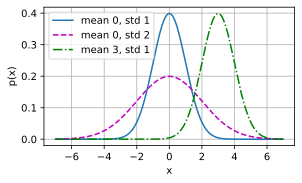

In [ ]:
import numpy as np
import math

# Use NumPy again for visualization
x = np.arange(-7, 7, 0.01)

# Mean and standard deviation pairs
params = [(0, 1), (0, 2), (3, 1)]
d2l.plot(x, [normal(x, mu, sigma) for mu, sigma in params], xlabel='x',
         ylabel='p(x)', figsize=(4.5, 2.5),
         legend=[f'mean {mu}, std {sigma}' for mu, sigma in params])

Note that changing the mean corresponds to a shift along the $x$-axis, and increasing the variance spreads the distribution out, lowering its peak.

One way to motivate linear regression with squared loss is to assume that observations arise from noisy measurements, where the noise $\epsilon$ follows the normal distribution $\mathcal{N}(0, \sigma^2)$:

$$y = \mathbf{w}^\top \mathbf{x} + b + \epsilon \textrm{ where } \epsilon \sim \mathcal{N}(0, \sigma^2). \tag{3.1.13}$$

Thus, we can now write out the *likelihood* of seeing a particular $y$ for a given $\mathbf{x}$ via

$$P(y \mid \mathbf{x}) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp\left(-\frac{1}{2 \sigma^2} (y - \mathbf{w}^\top \mathbf{x} - b)^2\right). \tag{3.1.14}$$

As such, the likelihood factorizes. According to *the principle of maximum likelihood*, the best values of parameters $\mathbf{w}$ and $b$ are those that maximize the *likelihood* of the entire dataset:

$$P(\mathbf y \mid \mathbf X) = \prod_{i=1}^{n} p(y^{(i)} \mid \mathbf{x}^{(i)}). \tag{3.1.15}$$

The equality follows since all pairs $(\mathbf{x}^{(i)}, y^{(i)})$ were drawn independently of each other. Estimators chosen according to the principle of maximum likelihood are called *maximum likelihood estimators*. While, maximizing the product of many exponential functions, might look difficult, we can simplify things significantly, without changing the objective, by maximizing the logarithm of the likelihood instead. For historical reasons, optimizations are more often expressed as minimization rather than maximization. So, without changing anything, we can *minimize* the *negative log-likelihood*, which we can express as follows:

$$-\log P(\mathbf y \mid \mathbf X) = \sum_{i=1}^n \frac{1}{2} \log(2 \pi \sigma^2) + \frac{1}{2 \sigma^2} \left(y^{(i)} - \mathbf{w}^\top \mathbf{x}^{(i)} - b\right)^2. \tag{3.1.16}$$

If we assume that $\sigma$ is fixed, we can ignore the first term, because it does not depend on $\mathbf{w}$ or $b$. The second term is identical to the squared error loss introduced earlier, except for the multiplicative constant $\frac{1}{\sigma^2}$. Fortunately, the solution does not depend on $\sigma$ either. It follows that minimizing the mean squared error is equivalent to the maximum likelihood estimation of a linear model under the assumption of additive Gaussian noise.

### 3.1.4. Linear Regression as a Neural Network

While linear models are not sufficiently rich to express the many complicated networks that we will introduce in this book, (artificial) neural networks are rich enough to subsume linear models as networks in which every feature is represented by an input neuron, all of which are connected directly to the output.

Fig. 3.1.2 depicts linear regression as a neural network. The diagram highlights the connectivity pattern, such as how each input is connected to the output, but not the specific values taken by the weights or biases.

<p align="center">
  <img src="http://d2l.ai/_images/singleneuron.svg"/>
  <br />
  <em>Fig. 3.1.2</em> Linear regression is a single-layer neural network.
</p>

The inputs are $x_1, \ldots, x_d$. We refer to $d$ as the *number of inputs* or the *feature dimensionality* in the input layer. The output of the network is $o_1$. Because we are just trying to predict a single numerical value, we have only one output neuron. Note that the input values are all *given*. There is just a single *computed* neuron. In summary, we can think of linear regression as a single-layer fully connected neural network. We will encounter networks with far more layers in later chapters.

---
牧之：神经网络的表现力实在太牛了，线性回归器竟然只是一个没有激活的神经元。

#### 3.1.4.1. Biology

Because linear regression predates computational neuroscience, it might seem anachronistic to describe linear regression in terms of neural networks. Nonetheless, they were a natural place to start when the cyberneticists and neurophysiologists Warren McCulloch and Walter Pitts began to develop models of artificial neurons. Consider the cartoonish picture of a biological neuron in Fig. 3.1.3, consisting of *dendrites* (input terminals), the *nucleus* (CPU), the *axon* (output wire), and the *axon terminals* (output terminals), enabling connections to other neurons via *synapses*.

<p align="center">
  <img src="http://d2l.ai/_images/neuron.svg"/>
  <br />
  <em>Fig. 3.1.3</em> The real neuron (source: “Anatomy and Physiology” by the US National Cancer Institute’s Surveillance, Epidemiology and End Results (SEER) Program).
</p>

Information $x_i$ arriving from other neurons (or environmental sensors) is received in the dendrites. In particular, that information is weighted by *synaptic weights* $w_i$, determining the effect of the inputs, e.g., activation or inhibition via the product $x_i w_i$. The weighted inputs arriving from multiple sources are aggregated in the nucleus as a weighted sum $y = \sum_i x_i w_i + b$, possibly subject to some nonlinear postprocessing via a function $\sigma(y)$. This information is then sent via the axon to the axon terminals, where it reaches its destination (e.g., an actuator such as a muscle) or it is fed into another neuron via its dendrites.

Certainly, the high-level idea that many such units could be combined, provided they have the correct connectivity and learning algorithm, to produce far more interesting and complex behavior than any one neuron alone could express arises from our study of real biological neural systems. At the same time, most research in deep learning today draws inspiration from a much wider source. We invoke Russell and Norvig (2016) who pointed out that although airplanes might have been *inspired* by birds, ornithology has not been the primary driver of aeronautics innovation for some centuries. Likewise, inspiration in deep learning these days comes in equal or greater measure from mathematics, linguistics, psychology, statistics, computer science, and many other fields.

### 3.1.5. Summary

In this section, we introduced traditional linear regression, where the parameters of a linear function are chosen to minimize squared loss on the training set. We also motivated this choice of objective both via some practical considerations and through an interpretation of linear regression as maximimum likelihood estimation under an assumption of linearity and Gaussian noise. After discussing both computational considerations and connections to statistics, we showed how such linear models could be expressed as simple neural networks where the inputs are directly wired to the output(s). While we will soon move past linear models altogether, they are sufficient to introduce most of the components that all of our models require: parametric forms, differentiable objectives, optimization via minibatch stochastic gradient descent, and ultimately, evaluation on previously unseen data.

### 3.1.6. Exercises

1. Assume that we have some data $x_1, \ldots, x_n \in \mathbb{R}$. Our goal is to find a constant $b$ such that $\sum_i (x_i - b)^2$ is minimized.
    - Find an analytic solution for the optimal value of $b$.
    - How does this problem and its solution relate to the normal distribution?
    - What if we change the loss from $\sum_i (x_i - b)^2$ to $\sum_i |x_i-b|$? Can you find the optimal solution for $b$?

1. Prove that the affine functions that can be expressed by $\mathbf{x}^\top \mathbf{w} + b$ are equivalent to linear functions on $(\mathbf{x}, 1)$.

1. Assume that you want to find quadratic functions of $\mathbf{x}$, i.e., $f(\mathbf{x}) = b + \sum_i w_i x_i + \sum_{j \leq i} w_{ij} x_{i} x_{j}$. How would you formulate this in a deep network?

1. Recall that one of the conditions for the linear regression problem to be solvable was that the design matrix $\mathbf{X}^\top \mathbf{X}$ has full rank.
    - What happens if this is not the case?
    - How could you fix it? What happens if you add a small amount of coordinate-wise independent Gaussian noise to all entries of $\mathbf{X}$?
    - What is the expected value of the design matrix $\mathbf{X}^\top \mathbf{X}$ in this case?
    - What happens with stochastic gradient descent when $\mathbf{X}^\top \mathbf{X}$ does not have full rank?

1. Assume that the noise model governing the additive noise $\epsilon$ is the exponential distribution. That is, $p(\epsilon) = \frac{1}{2} \exp(-|\epsilon|)$.
    - Write out the negative log-likelihood of the data under the model $-\log P(\mathbf y \mid \mathbf X)$.
    - Can you find a closed form solution?
    - Suggest a minibatch stochastic gradient descent algorithm to solve this problem. What could possibly go wrong (hint: what happens near the stationary point as we keep on updating the parameters)? Can you fix this?

1. Assume that we want to design a neural network with two layers by composing two linear layers. That is, the output of the first layer becomes the input of the second layer. Why would such a naive composition not work?

1. What happens if you want to use regression for realistic price estimation of houses or stock prices?
    - Show that the additive Gaussian noise assumption is not appropriate. Hint: can we have negative prices? What about fluctuations?
    - Why would regression to the logarithm of the price be much better, i.e., $y = \log \textrm{price}$?
    - What do you need to worry about when dealing with pennystock, i.e., stock with very low prices? Hint: can you trade at all possible prices? Why is this a bigger problem for cheap stock? For more information review the celebrated Black--Scholes model for option pricing (Black and Scholes, 1973).

1. Suppose we want to use regression to estimate the *number* of apples sold in a grocery store.
    - What are the problems with a Gaussian additive noise model? Hint: you are selling apples, not oil.
    - The [Poisson distribution](https://en.wikipedia.org/wiki/Poisson_distribution) captures distributions over counts. It is given by $p(k \mid \lambda) = \lambda^k e^{-\lambda}/k!$. Here $\lambda$ is the rate function and $k$ is the number of events you see. Prove that $\lambda$ is the expected value of counts $k$.
    - Design a loss function associated with the Poisson distribution.
    - Design a loss function for estimating $\log \lambda$ instead.

Q8 - 文心：

**高斯加性噪声模型在估计苹果销售量时的问题**

高斯（Gaussian）或正态分布通常用于描述连续变量的噪声，例如温度、重量等。然而，在估计苹果的销售量时，我们面对的是一个离散变量——即销售的数量必须是整数。高斯分布的值域是实数集，它包含了非整数值，这在物理意义上对苹果销售量的建模是不合适的。此外，高斯分布的尾部会延伸到负无穷，这在销售量（一个非负量）上也是没有意义的。

**泊松分布中 $\lambda$ 是 $k$ 的期望值的证明**

泊松分布 $p(k \mid \lambda) = \frac{\lambda^k e^{-\lambda}}{k!}$ 描述了在固定时间或空间内，发生 $k$ 次事件的概率，其中 $\lambda$ 是单位时间（或单位空间）内事件的平均发生率。

要证明 $\lambda$ 是 $k$ 的期望值，我们计算 $k$ 的期望 $E[k]$：

$$
E[k] = \sum_{k=0}^{\infty} k \cdot p(k \mid \lambda) = \sum_{k=0}^{\infty} k \cdot \frac{\lambda^k e^{-\lambda}}{k!}
$$

由于 $k \cdot \frac{1}{k!} = \frac{1}{(k-1)!}$ 当 $k \geq 1$，且 $0 \cdot \frac{1}{0!} = 0$，上式可以改写为：

$$
E[k] = \sum_{k=1}^{\infty} \frac{\lambda^k e^{-\lambda}}{(k-1)!} = \lambda \sum_{k=1}^{\infty} \frac{\lambda^{k-1} e^{-\lambda}}{(k-1)!}
$$

注意到 $\sum_{k=1}^{\infty} \frac{\lambda^{k-1} e^{-\lambda}}{(k-1)!}$ 实际上是 $e^\lambda$ 的泰勒级数（除了第一项），但由于我们从 $k=1$ 开始，实际上它等于 $e^\lambda - \frac{\lambda^0 e^{-\lambda}}{0!} = e^\lambda - 1$。但由于 $k=0$ 的项为 0，因此这个和实际上就是 $e^\lambda$。

因此：

$$
E[k] = \lambda \cdot e^\lambda = \lambda \cdot \sum_{k=0}^{\infty} \frac{\lambda^k e^{-\lambda}}{k!} = \lambda \cdot 1 = \lambda
$$

这里我们用到了 $\sum_{k=0}^{\infty} \frac{\lambda^k e^{-\lambda}}{k!} = 1$，即泊松分布的全概率为 1。

**设计与泊松分布相关的损失函数**

在机器学习中，我们通常希望最小化损失函数来优化模型参数。对于泊松分布，一个自然的损失函数是负对数似然函数（NLL），因为它直接对应于数据的对数概率，易于优化。

给定数据点 ${ (x_i, k_i) }_{i=1}^N$，其中 $x_i$ 是输入特征（如日期、促销活动等），$k_i$ 是观测到的销售量，损失函数为：

$$
L = -\sum_{i=1}^N \log p(k_i \mid \lambda_i) = -\sum_{i=1}^N \left( k_i \log \lambda_i - \lambda_i - \log(k_i!) \right)
$$

注意，$\log(k_i!)$ 是常数项（对于给定的 $k_i$），不影响优化过程中的梯度，因此可以省略。

**设计估计 $\log \lambda$ 的损失函数**

在某些情况下，直接估计 $\log \lambda$ 可能是有益的，特别是当 $\lambda$ 的值范围很广时。这样做可以减少数值问题，因为 $\log \lambda$ 可以将大范围的值映射到更紧凑的区间。

对于这种情况，我们可以将原损失函数中的 $\lambda_i$ 替换为 $\exp(\theta_i)$，其中 $\theta_i$ 是模型输出的 $\log \lambda_i$ 的估计值。因此，损失函数变为：

$$
L = -\sum_{i=1}^N \left( k_i \theta_i - e^{\theta_i} - \log(k_i!) \right)
$$

同样地，$\log(k_i!)$ 是常数项，可以省略。

## 3.2. Object-Oriented Design for Implementation

In our introduction to linear regression, we walked through various components including the data, the model, the loss function, and the optimization algorithm. Indeed, linear regression is one of the simplest machine learning models. Training it, however, uses many of the same components that other models in this book require. Therefore, before diving into the implementation details it is worth designing some of the APIs that we use throughout. Treating components in deep learning as objects, we can start by defining classes for these objects and their interactions. This object-oriented design for implementation will greatly streamline the presentation and you might even want to use it in your projects.

Inspired by open-source libraries such as [PyTorch Lightning](https://www.pytorchlightning.ai/), at a high level we wish to have three classes: (i) `Module` contains models, losses, and optimization methods; (ii) `DataModule` provides data loaders for training and validation; (iii) both classes are combined using the `Trainer` class, which allows us to train models on a variety of hardware platforms. Most code in this book adapts `Module` and `DataModule`. We will touch upon the `Trainer` class only when we discuss GPUs, CPUs, parallel training, and optimization algorithms.

In [ ]:
import time
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

### 3.2.1. Utilities

We need a few utilities to simplify object-oriented programming in Jupyter notebooks. One of the challenges is that class definitions tend to be fairly long blocks of code. Notebook readability demands short code fragments, interspersed with explanations, a requirement incompatible with the style of programming common for Python libraries. The first utility function allows us to register functions as methods in a class *after* the class has been created. In fact, we can do so *even after* we have created instances of the class! It allows us to split the implementation of a class into multiple code blocks.

In [ ]:
def add_to_class(Class):  #@ save
    """Register functions as methods in created class."""
    def wrapper(obj):
        setattr(Class, obj.__name__, obj)
    return wrapper

Let's have a quick look at how to use it. We plan to implement a class `A` with a method `do`. Instead of having code for both `A` and `do` in the same code block, we can first declare the class `A` and create an instance `a`.

---
通义：`setattr(Class, obj.__name__, obj)` 这一行代码在 Python 中的作用是为类 Class 添加一个新的属性，这个属性的名称就是当前函数 `obj` 的名称，而其值则是 `obj` 函数本身。这行代码的具体含义如下：

1. `setattr()` 函数：`setattr()` 是 Python 的内置函数，用于设置对象的属性。它接受三个参数：
  - 第一个参数是要设置属性的对象（在这里是 Class）。
  - 第二个参数是属性的名称。
  - 第三个参数是属性的值。

1. `obj.__name__`：在 Python 中，每个函数都有一个属性叫做 `__name__`，它存储了函数的名称。因此，`obj.__name__` 获取的就是当前函数 `obj` 的名称。

1. `obj`：这是要添加到类 Class 中的属性的实际值。由于 `obj` 是一个函数，因此将其添加为属性意味着这个函数现在可以作为类 Class 的一个方法来调用。

综上所述，`setattr(Class, obj.__name__, obj)` 实际上是在类 Class 上创建了一个新的方法，其名称是 `obj` 函数的名称，而该方法的行为就是执行 `obj` 函数的逻辑。这种操作允许我们在类定义之后动态地添加新的方法，这对于编写可扩展的、动态的代码非常有用。

In [ ]:
class A:
    def __init__(self):
        self.b = 1

a = A()

Next we define the method `do` as we normally would, but not in class `A`'s scope. Instead, we decorate this method by `add_to_class` with class `A` as its argument. In doing so, the method is able to access the member variables of `A` just as we would expect had it been included as part of `A`'s definition. Let's see what happens when we invoke it for the instance `a`.

In [ ]:
@add_to_class(A)
def do(self):
    print('Class attribute "b" is', self.b)

a.do()

Class attribute "b" is 1


The second one is a utility class that saves all arguments in a class's `__init__` method as class attributes. This allows us to extend constructor call signatures implicitly without additional code.

In [ ]:
class HyperParameters:  #@ save
    """The base class of hyperparameters."""
    def save_hyperparameters(self, ignore=[]):
        raise NotImplemented

We defer its implementation into Section 23.7. To use it, we define our class that inherits from `HyperParameters` and calls `save_hyperparameters` in the `__init__` method.

In [ ]:
# Call the fully implemented HyperParameters class saved in d2l
class B(d2l.HyperParameters):
    def __init__(self, a, b, c):
        self.save_hyperparameters(ignore=['c'])
        print('self.a =', self.a, 'self.b =', self.b)
        print('There is no self.c =', not hasattr(self, 'c'))

b = B(a=1, b=2, c=3)

self.a = 1 self.b = 2
There is no self.c = True


The final utility allows us to plot experiment progress interactively while it is going on. In deference to the much more powerful (and complex) [TensorBoard](https://www.tensorflow.org/tensorboard) we name it `ProgressBoard`. The  implementation is deferred to Section 23.7. For now, let's simply see it in action.

The `draw` method plots a point `(x, y)` in the figure, with `label` specified in the legend. The optional `every_n` smooths the line by only showing $1/n$ points in the figure. Their values are averaged from the $n$ neighbor points in the original figure.

In [ ]:
class ProgressBoard(d2l.HyperParameters):  #@ save
    """The board that plots data points in animation."""
    def __init__(self, xlabel=None, ylabel=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 ls=['-', '--', '-.', ':'], colors=['C0', 'C1', 'C2', 'C3'],
                 fig=None, axes=None, figsize=(3.5, 2.5), display=True):
        self.save_hyperparameters()

    def draw(self, x, y, label, every_n=1):
        raise NotImplemented

In the following example, we draw `sin` and `cos` with a different smoothness. If you run this code block, you will see the lines grow in animation.

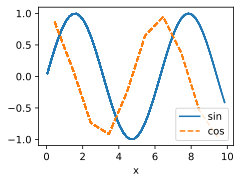

In [ ]:
board = d2l.ProgressBoard('x')
for x in np.arange(0, 10, 0.1):
    board.draw(x, np.sin(x), 'sin', every_n=2)
    board.draw(x, np.cos(x), 'cos', every_n=10)

### 3.2.2. Models

The `Module` class is the base class of all models we will implement. At the very least we need three methods. The first, `__init__`, stores the learnable parameters, the `training_step` method accepts a data batch to return the loss value, and finally, `configure_optimizers` returns the optimization method, or a list of them, that is used to update the learnable parameters. Optionally we can define `validation_step` to report the evaluation measures. Sometimes we put the code for computing the output into a separate `forward` method to make it more reusable.

In [ ]:
class Module(nn.Module, d2l.HyperParameters):  #@ save
    """The base class of models."""
    def __init__(self, plot_train_per_epoch=2, plot_valid_per_epoch=1):
        super().__init__()
        self.save_hyperparameters()
        self.board = ProgressBoard()

    def loss(self, y_hat, y):
        raise NotImplementedError

    def forward(self, X):
        assert hasattr(self, 'net'), 'Neural network is not defined'
        return self.net(X)

    def plot(self, key, value, train):
        """Plot a point in animation."""
        assert hasattr(self, 'trainer'), 'Trainer is not inited'
        self.board.xlabel = 'epoch'
        if train:
            x = self.trainer.train_batch_idx / \
                self.trainer.num_train_batches
            n = self.trainer.num_train_batches / \
                self.plot_train_per_epoch
        else:
            x = self.trainer.epoch + 1
            n = self.trainer.num_val_batches / \
                self.plot_valid_per_epoch
        self.board.draw(x, value.to(d2l.cpu()).detach().numpy(),
                        ('train_' if train else 'val_') + key,
                        every_n=int(n))

    def training_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('loss', l, train=True)
        return l

    def validation_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('loss', l, train=False)

    def configure_optimizers(self):
        raise NotImplementedError

---
牧之：
- 参考 `l = self.loss(self(*batch[:-1]), batch[-1])` 语句，说明把 feature 和 label 组成 dataset 使用已是约定俗成的方式。
- 传入的 `plot_train_per_epoch` 是想要画出来的点数，所以才会有 `n = self.trainer.num_train_batches / self.plot_train_per_epoch` 这个转换。
- 使用 `x = self.trainer.epoch + 1` 是因为，无论 `training_step` 还是 `validation_step`，都是在某个具体 epoch 中逐批次调用的，对于训练而言，还有分数表示 epoch 的必要，但对验证来说，确实没有分数表示 epoch 的必要。不过，这也意味着如果要修改 `plot_valid_per_epoch=1` 默认参数，是没有意义的。对于验证集而言，每个 epoch 只会显示 1 个点，这个点逐本 epoch 内的所有批次平滑过了。

You may notice that `Module` is a subclass of `nn.Module`, the base class of neural networks in PyTorch. It provides convenient features for handling neural networks. For example, if we define a `forward` method, such as `forward(self, X)`, then for an instance `a` we can invoke this method by `a(X)`. This works since it calls the `forward` method in the built-in `__call__` method. You can find more details and examples about `nn.Module` in Section 6.1.

### 3.2.3. Data

The `DataModule` class is the base class for data. Quite frequently the `__init__` method is used to prepare the data. This includes downloading and preprocessing if needed. The `train_dataloader` returns the data loader for the training dataset. A data loader is a (Python) generator that yields a data batch each time it is used. This batch is then fed into the `training_step` method of `Module` to compute the loss. There is an optional `val_dataloader` to return the validation dataset loader. It behaves in the same manner, except that it yields data batches for the `validation_step` method in `Module`.

In [ ]:
class DataModule(d2l.HyperParameters):  #@ save
    """The base class of data."""
    def __init__(self, root='../data', num_workers=4):
        self.save_hyperparameters()

    def get_dataloader(self, train):
        raise NotImplementedError

    def train_dataloader(self):
        return self.get_dataloader(train=True)

    def val_dataloader(self):
        return self.get_dataloader(train=False)

### 3.2.4. Training

The `Trainer` class trains the learnable parameters in the `Module` class with data specified in `DataModule`. The key method is `fit`, which accepts two arguments: `model`, an instance of `Module`, and `data`, an instance of `DataModule`. It then iterates over the entire dataset `max_epochs` times to train the model. As before, we will defer the implementation of this method to later chapters.

In [ ]:
class Trainer(d2l.HyperParameters):  #@ save
    """The base class for training models with data."""
    def __init__(self, max_epochs, num_gpus=0, gradient_clip_val=0):
        self.save_hyperparameters()
        assert num_gpus == 0, 'No GPU support yet'

    def prepare_data(self, data):
        self.train_dataloader = data.train_dataloader()
        self.val_dataloader = data.val_dataloader()
        self.num_train_batches = len(self.train_dataloader)
        self.num_val_batches = (len(self.val_dataloader)
                                if self.val_dataloader is not None else 0)

    def prepare_model(self, model):
        model.trainer = self
        model.board.xlim = [0, self.max_epochs]
        self.model = model

    def fit(self, model, data):
        self.prepare_data(data)
        self.prepare_model(model)
        self.optim = model.configure_optimizers()
        self.epoch = 0
        self.train_batch_idx = 0
        self.val_batch_idx = 0
        for self.epoch in range(self.max_epochs):
            self.fit_epoch()

    def fit_epoch(self):
        raise NotImplementedError

### 3.2.5. Summary

To highlight the object-oriented design for our future deep learning implementation, the above classes simply show how their objects store data and interact with each other. We will keep enriching implementations of these classes, such as via `@add_to_class`, in the rest of the book. Moreover, these fully implemented classes are saved in the [D2L library](https://github.com/d2l-ai/d2l-en/tree/master/d2l), a *lightweight toolkit* that makes structured modeling for deep learning easy. In particular, it facilitates reusing many components between projects without changing much at all. For instance, we can replace just the optimizer, just the model, just the dataset, etc.; this degree of modularity pays dividends throughout the book in terms of conciseness and simplicity (this is why we added it) and it can do the same for your own projects.

### 3.2.6. Exercises

1. Locate full implementations of the above classes that are saved in the [D2L library](https://github.com/d2l-ai/d2l-en/tree/master/d2l). We strongly recommend that you look at the implementation in detail once you have gained some more familiarity with deep learning modeling.

1. Remove the `save_hyperparameters` statement in the `B` class. Can you still print `self.a` and `self.b`? Optional: if you have dived into the full implementation of the `HyperParameters` class, can you explain why?

## 3.3. Synthetic Regression Data

Machine learning is all about extracting information from data. So you might wonder, what could we possibly learn from synthetic data? While we might not care intrinsically about the patterns that we ourselves baked into an artificial data generating model, such datasets are nevertheless useful for didactic purposes, helping us to evaluate the properties of our learning algorithms and to confirm that our implementations work as expected. For example, if we create data for which the correct parameters are known *a priori*, then we can check that our model can in fact recover them.

In [ ]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

### 3.3.1. Generating the Dataset

For this example, we will work in low dimension for succinctness. The following code snippet generates 1000 examples with 2-dimensional features drawn from a standard normal distribution. The resulting design matrix $\mathbf{X}$ belongs to $\mathbb{R}^{1000 \times 2}$. We generate each label by applying a *ground truth* linear function, corrupting them via additive noise $\boldsymbol{\epsilon}$, drawn independently and identically for each example:

$$\mathbf{y}= \mathbf{X} \mathbf{w} + b + \boldsymbol{\epsilon}. \tag{3.3.1}$$

For convenience we assume that $\boldsymbol{\epsilon}$ is drawn from a normal distribution with mean $\mu= 0$ and standard deviation $\sigma = 0.01$. Note that for object-oriented design we add the code to the `__init__` method of a subclass of `d2l.DataModule` (introduced in Section 3.2.3). It is good practice to allow the setting of any additional hyperparameters. We accomplish this with `save_hyperparameters()`. The `batch_size` will be determined later.

In [ ]:
class SyntheticRegressionData(d2l.DataModule):  #@ save
    """Synthetic data for linear regression."""
    def __init__(self, w, b, noise=0.01, num_train=1000, num_val=1000,
                 batch_size=32):
        super().__init__()
        self.save_hyperparameters()
        n = num_train + num_val
        self.X = torch.randn(n, len(w))
        noise = torch.randn(n, 1) * noise
        self.y = torch.matmul(self.X, w.reshape((-1, 1))) + b + noise

---
牧之：正态分布的性质之一是，如果 $X$ 是一个服从标准正态分布（均值为 $0$，标准差为 $1$）的随机变量，那么 $aX$ 就是一个服从均值为 $0$、标准差为 $|a|$ 的正态分布的随机变量。因此，当我们将服从标准正态分布的随机数矩阵 `torch.randn(n, 1)` 乘以标准差 `noise` 时，得到的结果矩阵中的每个元素都相当于乘以了标准差 `noise`，因此结果矩阵中的元素服从均值为 $0$、标准差为 `noise` 的正态分布。

Below, we set the true parameters to $\mathbf{w} = [2, -3.4]^\top$ and $b = 4.2$.
Later, we can check our estimated parameters against these *ground truth* values.

In [ ]:
data = SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)

Each row in `features` consists of a vector in $\mathbb{R}^2$ and each row in `labels` is a scalar. Let's have a look at the first entry.

In [ ]:
print('features:', data.X[0],'\nlabel:', data.y[0])

features: tensor([-2.2458, -0.0482]) 
label: tensor([-0.1245])


By generating a scatter plot of the second feature `features[:, 1]` and `labels`, we can intuitively observe the linear relationship between the two.

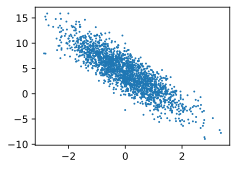

In [ ]:
d2l.set_figsize()
d2l.plt.scatter(data.X[:, 1].detach().numpy(), data.y.detach().numpy(), 1);

### 3.3.2. Reading the Dataset

Training machine learning models often requires multiple passes over a dataset, grabbing one minibatch of examples at a time. This data is then used to update the model. To illustrate how this works, we implement the `get_dataloader` method, registering it in the `SyntheticRegressionData` class via `add_to_class` (introduced in Section 3.2.1). It takes a batch size, a matrix of features, and a vector of labels, and generates minibatches of size `batch_size`. As such, each minibatch consists of a tuple of features and labels. Note that we need to be mindful of whether we're in training or validation mode: in the former, we will want to read the data in random order, whereas for the latter, being able to read data in a pre-defined order may be important for debugging purposes.

In [ ]:
@d2l.add_to_class(SyntheticRegressionData)
def get_dataloader(self, train):
    if train:
        indices = list(range(0, self.num_train))
        # The examples are read in random order
        random.shuffle(indices)
    else:
        indices = list(range(self.num_train, self.num_train+self.num_val))
    for i in range(0, len(indices), self.batch_size):
        batch_indices = torch.tensor(indices[i: i+self.batch_size])
        yield self.X[batch_indices], self.y[batch_indices]

---
牧之：貌似这里调用都会洗牌，之后再抽取一个批次，这就意味着每次都是放回抽样。不过，参考 3.4.4 章节，`get_dataloader` 只是在每个 epoch 会被调用，在一个特定的 epoch 迭代所有批次时，并不会被调用。

To build some intuition, let's inspect the first minibatch of data. Each minibatch of features provides us with both its size and the dimensionality of input features. Likewise, our minibatch of labels will have a matching shape given by `batch_size`.

In [ ]:
X, y = next(iter(data.train_dataloader()))
print('X shape:', X.shape, '\ny shape:', y.shape)

X shape: torch.Size([32, 2]) 
y shape: torch.Size([32, 1])


While seemingly innocuous, the invocation of `iter(data.train_dataloader())` illustrates the power of Python's object-oriented design. Note that we added a method to the `SyntheticRegressionData` class *after* creating the `data` object. Nonetheless, the object benefits from the *ex post facto* addition of functionality to the class.

Throughout the iteration we obtain distinct minibatches until the entire dataset has been exhausted (try this). While the iteration implemented above is good for didactic purposes, it is inefficient in ways that might get us into trouble with real problems. For example, it requires that we load all the data in memory and that we perform lots of random memory access. The built-in iterators implemented in a deep learning framework are considerably more efficient and they can deal with sources such as data stored in files, data received via a stream, and data generated or processed on the fly. Next let's try to implement the same method using built-in iterators.

### 3.3.3. Concise Implementation of the Data Loader

Rather than writing our own iterator, we can call the existing API in a framework to load data. As before, we need a dataset with features `X` and labels `y`. Beyond that, we set `batch_size` in the built-in data loader and let it take care of shuffling examples  efficiently.

In [ ]:
@d2l.add_to_class(d2l.DataModule)  #@ save
def get_tensorloader(self, tensors, train, indices=slice(0, None)):
    tensors = tuple(a[indices] for a in tensors)
    dataset = torch.utils.data.TensorDataset(*tensors)
    return torch.utils.data.DataLoader(dataset, self.batch_size,
                                       shuffle=train)

@d2l.add_to_class(SyntheticRegressionData)  #@ save
def get_dataloader(self, train):
    i = slice(0, self.num_train) if train else slice(self.num_train, None)
    return self.get_tensorloader((self.X, self.y), train, i)

The new data loader behaves just like the previous one, except that it is more efficient and has some added functionality.

In [ ]:
X, y = next(iter(data.train_dataloader()))
print('X shape:', X.shape, '\ny shape:', y.shape)

X shape: torch.Size([32, 2]) 
y shape: torch.Size([32, 1])


For instance, the data loader provided by the framework API supports the built-in `__len__` method, so we can query its length, i.e., the number of batches.

In [ ]:
len(data.train_dataloader())

32

### 3.3.4. Summary

Data loaders are a convenient way of abstracting out the process of loading and manipulating data. This way the same machine learning *algorithm* is capable of processing many different types and sources of data without the need for modification. One of the nice things about data loaders is that they can be composed. For instance, we might be loading images and then have a postprocessing filter that crops them or modifies them in other ways. As such, data loaders can be used to describe an entire data processing pipeline.

As for the model itself, the two-dimensional linear model is about the simplest we might encounter. It lets us test out the accuracy of regression models without worrying about having insufficient amounts of data or an underdetermined system of equations. We will put this to good use in the next section.

### 3.3.5. Exercises

1. What will happen if the number of examples cannot be divided by the batch size. How would you change this behavior by specifying a different argument by using the framework's API?

1. Suppose that we want to generate a huge dataset, where both the size of the parameter vector `w` and the number of examples `num_examples` are large.
    - What happens if we cannot hold all data in memory?
    - How would you shuffle the data if it is held on disk? Your task is to design an *efficient* algorithm that does not require too many random reads or writes. Hint: [pseudorandom permutation generators](https://en.wikipedia.org/wiki/Pseudorandom_permutation) allow you to design a reshuffle without the need to store the permutation table explicitly (Naor and Reingold, 1999).

1. Implement a data generator that produces new data on the fly, every time the iterator is called.

1. How would you design a random data generator that generates *the same* data each time it is called?

## 3.4. Linear Regression Implementation from Scratch

We are now ready to work through a fully functioning implementation of linear regression. In this section, we will implement the entire method from scratch, including (i) the model; (ii) the loss function; (iii) a minibatch stochastic gradient descent optimizer; and (iv) the training function that stitches all of these pieces together. Finally, we will run our synthetic data generator from Section 3.3 and apply our model on the resulting dataset. While modern deep learning frameworks can automate nearly all of this work, implementing things from scratch is the only way to make sure that you really know what you are doing. Moreover, when it is time to customize models, defining our own layers or loss functions, understanding how things work under the hood will prove handy. In this section, we will rely only on tensors and automatic differentiation. Later, we will introduce a more concise implementation, taking advantage of the bells and whistles of deep learning frameworks while retaining the structure of what follows below.

In [ ]:
%matplotlib inline
import torch
from d2l import torch as d2l

### 3.4.1. Defining the Model

Before we can begin optimizing our model's parameters by minibatch SGD, we need to have some parameters in the first place. In the following we initialize weights by drawing random numbers from a normal distribution with mean 0 and a standard deviation of 0.01. The magic number 0.01 often works well in practice, but you can specify a different value through the argument `sigma`. Moreover we set the bias to 0. Note that for object-oriented design we add the code to the `__init__` method of a subclass of `d2l.Module` (introduced in Section 3.2.2).

In [ ]:
class LinearRegressionScratch(d2l.Module):  #@ save
    """The linear regression model implemented from scratch."""
    def __init__(self, num_inputs, lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.w = torch.normal(0, sigma, (num_inputs, 1), requires_grad=True)
        self.b = torch.zeros(1, requires_grad=True)

---
牧之：这是一个线性回归，为什么要把 `w` 的形状定义成二维的 `(num_inputs, 1)`，而不是一维的 `(num_inputs,)`？

GPT：在这个例子中，将权重参数 `w` 定义为二维的 `(num_inputs, 1)` 是为了匹配矩阵乘法的要求。在线性回归中，输入特征通常表示为一个矩阵 `X`，其中每一行是一个样本，每一列对应于一个特征。通过将 `w` 定义为二维的 `(num_inputs, 1)`，可以确保当进行矩阵乘法 `Xw` 时，能够正确地进行特征权重的运算，得到每个样本的预测结果，而不仅仅是元素级的乘法。

Next we must define our model, relating its input and parameters to its output. Using the same notation as (3.1.4) for our linear model we simply take the matrix--vector product of the input features $\mathbf{X}$ and the model weights $\mathbf{w}$, and add the offset $b$ to each example. The product $\mathbf{Xw}$ is a vector and $b$ is a scalar. Because of the broadcasting mechanism (see Section 2.1.4), when we add a vector and a scalar, the scalar is added to each component of the vector. The resulting `forward` method is registered in the `LinearRegressionScratch` class via `add_to_class` (introduced in Section 3.2.1).

In [ ]:
@d2l.add_to_class(LinearRegressionScratch)  #@ save
def forward(self, X):
    return torch.matmul(X, self.w) + self.b

### 3.4.2. Defining the Loss Function

Since updating our model requires taking the gradient of our loss function, we ought to define the loss function first. Here we use the squared loss function in (3.1.5). In the implementation, we need to transform the true value `y` into the predicted value's shape `y_hat`. The result returned by the following method will also have the same shape as `y_hat`. We also return the averaged loss value among all examples in the minibatch.

In [ ]:
@d2l.add_to_class(LinearRegressionScratch)  #@ save
def loss(self, y_hat, y):
    l = (y_hat - y) ** 2 / 2
    return l.mean()

### 3.4.3. Defining the Optimization Algorithm

As discussed in Section 3.1, linear regression has a closed-form solution. However, our goal here is to illustrate how to train more general neural networks, and that requires that we teach you how to use minibatch SGD. Hence we will take this opportunity to introduce your first working example of SGD. At each step, using a minibatch randomly drawn from our dataset, we estimate the gradient of the loss with respect to the parameters. Next, we update the parameters in the direction that may reduce the loss.

The following code applies the update, given a set of parameters, a learning rate `lr`. Since our loss is computed as an average over the minibatch, we do not need to adjust the learning rate against the batch size. In later chapters we will investigate how learning rates should be adjusted for very large minibatches as they arise in distributed large-scale learning. For now, we can ignore this dependency.

In [ ]:
class SGD(d2l.HyperParameters):  #@ save
    """Minibatch stochastic gradient descent."""
    def __init__(self, params, lr):
        self.save_hyperparameters()

    def step(self):
        for param in self.params:
            param -= self.lr * param.grad

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

We next define the `configure_optimizers` method, which returns an instance of the `SGD` class.

In [ ]:
@d2l.add_to_class(LinearRegressionScratch)  #@ save
def configure_optimizers(self):
    return SGD([self.w, self.b], self.lr)

### 3.4.4. Training

Now that we have all of the parts in place (parameters, loss function, model, and optimizer), we are ready to implement the main training loop. It is crucial that you understand this code fully since you will employ similar training loops for every other deep learning model covered in this book. In each *epoch*, we iterate through the entire training dataset, passing once through every example (assuming that the number of examples is divisible by the batch size). In each *iteration*, we grab a minibatch of training examples, and compute its loss through the model's `training_step` method. Then we compute the gradients with respect to each parameter. Finally, we will call the optimization algorithm to update the model parameters. In summary, we will execute the following loop:

* Initialize parameters $(\mathbf{w}, b)$
* Repeat until done
  * Compute gradient $\mathbf{g} \leftarrow \partial_{(\mathbf{w},b)} \frac{1}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} l(\mathbf{x}^{(i)}, y^{(i)}, \mathbf{w}, b)$
  * Update parameters $(\mathbf{w}, b) \leftarrow (\mathbf{w}, b) - \eta \mathbf{g}$

Recall that the synthetic regression dataset that we generated in Section 3.3 does not provide a validation dataset. In most cases, however, we will want a validation dataset to measure our model quality. Here we pass the validation dataloader once in each epoch to measure the model performance. Following our object-oriented design, the `prepare_batch` and `fit_epoch` methods are registered in the `d2l.Trainer` class (introduced in Section 3.2.4).

In [ ]:
@d2l.add_to_class(d2l.Trainer)  #@ save
def prepare_batch(self, batch):
    return batch

@d2l.add_to_class(d2l.Trainer)  #@ save
def fit_epoch(self):
    self.model.train()
    for batch in self.train_dataloader:
        loss = self.model.training_step(self.prepare_batch(batch))
        self.optim.zero_grad()
        with torch.no_grad():
            loss.backward()
            if self.gradient_clip_val > 0:  # To be discussed later
                self.clip_gradients(self.gradient_clip_val, self.model)
            self.optim.step()
        self.train_batch_idx += 1
    if self.val_dataloader is None:
        return
    self.model.eval()
    for batch in self.val_dataloader:
        with torch.no_grad():
            self.model.validation_step(self.prepare_batch(batch))
        self.val_batch_idx += 1

We are almost ready to train the model, but first we need some training data. Here we use the `SyntheticRegressionData` class and pass in some ground truth parameters. Then we train our model with the learning rate `lr=0.03` and set `max_epochs=3`. Note that in general, both the number of epochs and the learning rate are hyperparameters. In general, setting hyperparameters is tricky and we will usually want to use a three-way split, one set for training, a second for hyperparameter selection, and the third reserved for the final evaluation. We elide these details for now but will revise them later.

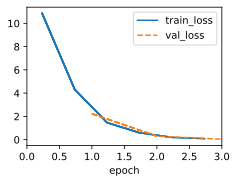

In [ ]:
model = LinearRegressionScratch(2, lr=0.03)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=3)
trainer.fit(model, data)

Because we synthesized the dataset ourselves, we know precisely what the true parameters are. Thus, we can evaluate our success in training by comparing the true parameters with those that we learned through our training loop. Indeed they turn out to be very close to each other.

In [ ]:
with torch.no_grad():
    print(f'error in estimating w: {data.w - model.w.reshape(data.w.shape)}')
    print(f'error in estimating b: {data.b - model.b}')

error in estimating w: tensor([ 0.1011, -0.1631])
error in estimating b: tensor([0.2033])


We should not take the ability to exactly recover the ground truth parameters for granted. In general, for deep models unique solutions for the parameters do not exist, and even for linear models, exactly recovering the parameters is only possible when no feature is linearly dependent on the others. However, in machine learning, we are often less concerned with recovering true underlying parameters, but rather with parameters that lead to highly accurate prediction (Vapnik, 1992). Fortunately, even on difficult optimization problems, stochastic gradient descent can often find remarkably good solutions, owing partly to the fact that, for deep networks, there exist many configurations of the parameters that lead to highly accurate prediction.

---
牧之：存在非常多的可以达到目标参数配置，这说明深度网络的表现力太强吗？使用具有这么强大表现力的工具，貌似是解决了问题，但让渡了可解释性。

### 3.4.5. Summary

In this section, we took a significant step towards designing deep learning systems by implementing a fully functional neural network model and training loop. In this process, we built a data loader, a model, a loss function, an optimization procedure, and a visualization and monitoring tool. We did this by composing a Python object that contains all relevant components for training a model. While this is not yet a professional-grade implementation it is perfectly functional and code like this could already help you to solve small problems quickly. In the coming sections, we will see how to do this both *more concisely* (avoiding boilerplate code) and *more efficiently* (using our GPUs to their full potential).

### 3.4.6. Exercises

1. What would happen if we were to initialize the weights to zero. Would the algorithm still work? What if we initialized the parameters with variance $1000$ rather than $0.01$?

1. Assume that you are [Georg Simon Ohm](https://en.wikipedia.org/wiki/Georg_Ohm) trying to come up with a model for resistance that relates voltage and current. Can you use automatic differentiation to learn the parameters of your model?

1. Can you use [Planck's Law](https://en.wikipedia.org/wiki/Planck%27s_law) to determine the temperature of an object using spectral energy density? For reference, the spectral density $B$ of radiation emanating from a black body is $B(\lambda, T) = \frac{2 hc^2}{\lambda^5} \cdot \left(\exp \frac{h c}{\lambda k T} - 1\right)^{-1}$. Here $\lambda$ is the wavelength, $T$ is the temperature, $c$ is the speed of light, $h$ is Planck's constant, and $k$ is the Boltzmann constant. You measure the energy for different wavelengths $\lambda$ and you now need to fit the spectral density curve to Planck's law.

1. What are the problems you might encounter if you wanted to compute the second derivatives of the loss? How would you fix them?

1. Why is the `reshape` method needed in the `loss` function?

1. Experiment using different learning rates to find out how quickly the loss function value drops. Can you reduce the error by increasing the number of epochs of training?

1. If the number of examples cannot be divided by the batch size, what happens to `data_iter` at the end of an epoch?

1. Try implementing a different loss function, such as the absolute value loss `(y_hat - d2l.reshape(y, y_hat.shape)).abs().sum()`.
  - Check what happens for regular data.
  - Check whether there is a difference in behavior if you actively perturb some entries, such as $y_5 = 10000$, of $\mathbf{y}$.
  - Can you think of a cheap solution for combining the best aspects of squared loss and absolute value loss? Hint: how can you avoid really large gradient values?

1. Why do we need to reshuffle the dataset? Can you design a case where a maliciously constructed dataset would break the optimization algorithm otherwise?

## 3.5. Concise Implementation of Linear Regression

Deep learning has witnessed a sort of Cambrian explosion over the past decade. The sheer number of techniques, applications and algorithms by far surpasses the progress of previous decades. This is due to a fortuitous combination of multiple factors, one of which is the powerful free tools offered by a number of open-source deep learning frameworks. Theano (Bergstra et al., 2010), DistBelief (Dean et al., 2012), and Caffe (Jia et al., 2014) arguably represent the first generation of such models that found widespread adoption. In contrast to earlier (seminal) works like SN2 (Simulateur Neuristique) (Bottou and Le Cun, 1988), which provided a Lisp-like programming experience, modern frameworks offer automatic differentiation and the convenience of Python. These frameworks allow us to automate and modularize the repetitive work of implementing gradient-based learning algorithms.

In Section 3.4, we relied only on (i) tensors for data storage and linear algebra; and (ii) automatic differentiation for calculating gradients. In practice, because data iterators, loss functions, optimizers, and neural network layers are so common, modern libraries implement these components for us as well. In this section, we will show you how to implement the linear regression model from Section 3.4 concisely by using high-level APIs of deep learning frameworks.

In [ ]:
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

### 3.5.1. Defining the Model

When we implemented linear regression from scratch in Section 3.4, we defined our model parameters explicitly and coded up the calculations to produce output using basic linear algebra operations. You *should* know how to do this. But once your models get more complex, and once you have to do this nearly every day, you will be glad of the assistance. The situation is similar to coding up your own blog from scratch. Doing it once or twice is rewarding and instructive, but you would be a lousy web developer if you spent a month reinventing the wheel.

For standard operations, we can use a framework's predefined layers, which allow us to focus on the layers used to construct the model rather than worrying about their implementation. Recall the architecture of a single-layer network as described in Fig. 3.1.2. The layer is called *fully connected*, since each of its inputs is connected to each of its outputs by means of a matrix--vector multiplication.

In PyTorch, the fully connected layer is defined in `Linear` and `LazyLinear` classes (available since version 1.8.0). The latter allows users to specify *merely* the output dimension, while the former additionally asks for how many inputs go into this layer. Specifying input shapes is inconvenient and may require nontrivial calculations (such as in convolutional layers). Thus, for simplicity, we will use such "lazy" layers whenever we can.

In [ ]:
class LinearRegression(d2l.Module):  #@ save
    """The linear regression model implemented with high-level APIs."""
    def __init__(self, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.LazyLinear(1)
        self.net.weight.data.normal_(0, 0.01)
        self.net.bias.data.fill_(0)

In the `forward` method we just invoke the built-in `__call__` method of the predefined layers to compute the outputs.

In [ ]:
@d2l.add_to_class(LinearRegression)  #@ save
def forward(self, X):
    return self.net(X)

### 3.5.2. Defining the Loss Function

The `MSELoss` class computes the mean squared error (without the $1/2$ factor in (3.1.5)). By default, `MSELoss` returns the **average loss** over examples. It is faster (and easier to use) than implementing our own.

In [ ]:
@d2l.add_to_class(LinearRegression)  #@ save
def loss(self, y_hat, y):
    fn = nn.MSELoss()
    return fn(y_hat, y)

### 3.5.3. Defining the Optimization Algorithm

Minibatch SGD is a standard tool for optimizing neural networks and thus PyTorch supports it alongside a number of variations on this algorithm in the `optim` module. When we instantiate an `SGD` instance, we specify the parameters to optimize over, obtainable from our model via `self.parameters()`, and the learning rate (`self.lr`) required by our optimization algorithm.

In [ ]:
@d2l.add_to_class(LinearRegression)  #@ save
def configure_optimizers(self):
    return torch.optim.SGD(self.parameters(), self.lr)

### 3.5.4. Training

You might have noticed that expressing our model through high-level APIs of a deep learning framework requires fewer lines of code. We did not have to allocate parameters individually, define our loss function, or implement minibatch SGD. Once we start working with much more complex models, the advantages of the high-level API will grow considerably.

Now that we have all the basic pieces in place, the training loop itself is the same as the one we implemented from scratch. So we just call the `fit` method (introduced in Section 3.2.4), which relies on the implementation of the `fit_epoch` method in Section 3.4, to train our model.

---
牧之：
- 注意，`configure_optimizers` 是在 `model` 实现的，所以 `optimizer` 可以关联 `model` 的 `parameters` 和 `loss`。在 `trainer` 里的 `fit_epoch` 方法，会通过 `data` 去生成 `loss`，进而通过 `optimizer` 更新 `parameters`。
- 这个设计还真的是非常解耦，只把 `model` 换掉了，`data` 和 `trainer` 都没有变。

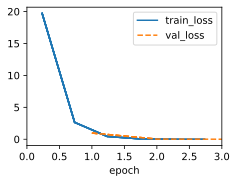

In [ ]:
model = LinearRegression(lr=0.03)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=3)
trainer.fit(model, data)

Below, we compare the model parameters learned by training on finite data and the actual parameters that generated our dataset. To access parameters, we access the weights and bias of the layer that we need. As in our implementation from scratch, note that our estimated parameters are close to their true counterparts.

In [ ]:
@d2l.add_to_class(LinearRegression)  #@ save
def get_w_b(self):
    return (self.net.weight.data, self.net.bias.data)
w, b = model.get_w_b()

print(f'error in estimating w: {data.w - w.reshape(data.w.shape)}')
print(f'error in estimating b: {data.b - b}')

error in estimating w: tensor([ 0.0051, -0.0145])
error in estimating b: tensor([0.0149])


### 3.5.5. Summary

This section contains the first implementation of a deep network (in this book) to tap into the conveniences afforded by modern deep learning frameworks, such as MXNet (Chen et al., 2015), JAX (Frostig et al., 2018), PyTorch (Paszke et al., 2019), and Tensorflow (Abadi et al., 2016). We used framework defaults for loading data, defining a layer, a loss function, an optimizer and a training loop. Whenever the framework provides all necessary features, it is generally a good idea to use them, since the library implementations of these components tend to be heavily optimized for performance and properly tested for reliability. At the same time, try not to forget that these modules *can* be implemented directly. This is especially important for aspiring researchers who wish to live on the leading edge of model development, where you will be inventing new components that cannot possibly exist in any current library.

In PyTorch, the `data` module provides tools for data processing, the `nn` module defines a large number of neural network layers and common loss functions. We can initialize the parameters by replacing their values with methods ending with `_`. Note that we need to specify the input dimensions of the network. While this is trivial for now, it can have significant knock-on effects when we want to design complex networks with many layers. Careful considerations of how to parametrize these networks is needed to allow portability.

### 3.5.6. Exercises

1. How would you need to change the learning rate if you replace the aggregate loss over the minibatch with an average over the loss on the minibatch?

1. Review the framework documentation to see which loss functions are provided. In particular, replace the squared loss with Huber's robust loss function. That is, use the loss function $$l(y,y') = \begin{cases}|y-y'| -\frac{\sigma}{2} & \textrm{ if } |y-y'| > \sigma \\ \frac{1}{2 \sigma} (y-y')^2 & \textrm{ otherwise}\end{cases}$$

1. How do you access the gradient of the weights of the model?

1. What is the effect on the solution if you change the learning rate and the number of epochs? Does it keep on improving?

1. How does the solution change as you vary the amount of data generated?
    - Plot the estimation error for $\hat{\mathbf{w}} - \mathbf{w}$ and $\hat{b} - b$ as a function of the amount of data. Hint: increase the amount of data logarithmically rather than linearly, i.e., 5, 10, 20, 50, ..., 10,000 rather than 1000, 2000, ..., 10,000.
    - Why is the suggestion in the hint appropriate?

## 3.6. Generalization

Consider two college students diligently preparing for their final exam. Commonly, this preparation will consist of practicing and testing their abilities by taking exams administered in previous years. Nonetheless, doing well on past exams is no guarantee that they will excel when it matters. For instance, imagine a student, Extraordinary Ellie, whose preparation consisted entirely of memorizing the answers to previous years' exam questions. Even if Ellie were endowed with an extraordinary memory, and thus could perfectly recall the answer to any *previously seen* question, she might nevertheless freeze when faced with a new (*previously unseen*) question. By comparison, imagine another student, Inductive Irene, with comparably poor memorization skills, but a knack for picking up patterns. Note that if the exam truly consisted of recycled questions from a previous year, Ellie would handily outperform Irene. Even if Irene's inferred patterns yielded 90% accurate predictions, they could never compete with Ellie's 100% recall. However, even if the exam consisted entirely of fresh questions, Irene might maintain her 90% average.

As machine learning scientists, our goal is to discover *patterns*. But how can we be sure that we have truly discovered a *general* pattern and not simply memorized our data? Most of the time, our predictions are only useful if our model discovers such a pattern. We do not want to predict yesterday's stock prices, but tomorrow's. We do not need to recognize already diagnosed diseases for previously seen patients, but rather previously undiagnosed ailments in previously unseen patients. This problem---how to discover patterns that *generalize*---is the fundamental problem of machine learning, and arguably of all of statistics. We might cast this problem as just one slice of a far grander question that engulfs all of science: when are we ever justified in making the leap from particular observations to more general statements?

In real life, we must fit our models using a finite collection of data. The typical scales of that data vary wildly across domains. For many important medical problems, we can only access a few thousand data points. When studying rare diseases, we might be lucky to access hundreds. By contrast, the largest public datasets consisting of labeled photographs, e.g., ImageNet (Deng et al., 2009), contain millions of images. And some unlabeled image collections such as the Flickr YFC100M dataset can be even larger, containing over 100 million images (Thomee et al., 2016). However, even at this extreme scale, the number of available data points remains infinitesimally small compared to the space of all possible images at a megapixel resolution. Whenever we work with finite samples, we must keep in mind the risk that we might fit our training data, only to discover that we failed to discover a generalizable pattern.

The phenomenon of fitting closer to our training data than to the underlying distribution is called *overfitting*, and techniques for combatting overfitting are often called *regularization* methods. While it is no substitute for a proper introduction to statistical learning theory (see Boucheron et al. (2005), Vapnik (1998)), we will give you just enough intuition to get going. We will revisit generalization in many chapters throughout the book, exploring both what is known about the principles underlying generalization in various models, and also heuristic techniques that have been found (empirically) to yield improved generalization on tasks of practical interest.

---
牧之：关于大学考试的例子太棒了，感觉与自己在大学考试的经历完全吻合，很早就在经历泛化的示例了。

### 3.6.1. Training Error and Generalization Error

In the standard supervised learning setting, we assume that the training data and the test data are drawn *independently* from *identical* distributions. This is commonly called the *IID assumption*. While this assumption is strong, it is worth noting that, absent any such assumption, we would be dead in the water. Why should we believe that training data sampled from distribution $P(X,Y)$ should tell us how to make predictions on test data generated by a *different distribution* $Q(X,Y)$? Making such leaps turns out to require strong assumptions about how $P$ and $Q$ are related. Later on we will discuss some assumptions that allow for shifts in distribution but first we need to understand the IID case, where $P(\cdot) = Q(\cdot)$.

To begin with, we need to differentiate between the *training error* $R_\textrm{emp}$, which is a *statistic* calculated on the training dataset, and the *generalization error* $R$, which is an *expectation* taken with respect to the underlying distribution. You can think of the generalization error as what you would see if you applied your model to an infinite stream of additional data examples drawn from the same underlying data distribution. Formally the training error is expressed as a *sum* (with the same notation as Section 3.1):

$$R_\textrm{emp}[\mathbf{X}, \mathbf{y}, f] = \frac{1}{n} \sum_{i=1}^n l(\mathbf{x}^{(i)}, y^{(i)}, f(\mathbf{x}^{(i)})), \tag{3.6.1}$$

while the generalization error is expressed as an integral:

$$R[p, f] = E_{(\mathbf{x}, y) \sim P} [l(\mathbf{x}, y, f(\mathbf{x}))] = \int \int l(\mathbf{x}, y, f(\mathbf{x})) p(\mathbf{x}, y) \;d\mathbf{x} dy. \tag{3.6.2}$$

Problematically, we can never calculate the generalization error $R$ exactly. Nobody ever tells us the precise form of the density function $p(\mathbf{x}, y)$. Moreover, we cannot sample an infinite stream of data points. Thus, in practice, we must *estimate* the generalization error by applying our model to an independent test set constituted of a random selection of examples $\mathbf{X}'$ and labels $\mathbf{y}'$ that were withheld from our training set. This consists of applying the same formula that was used for calculating the empirical training error but to a test set $\mathbf{X}', \mathbf{y}'$.

Crucially, when we evaluate our classifier on the test set, we are working with a *fixed* classifier (it does not depend on the sample of the test set), and thus estimating its error is simply the problem of mean estimation. However the same cannot be said for the training set. Note that the model we wind up with depends explicitly on the selection of the training set and thus the training error will in general be a *biased estimate* of the true error on the underlying population. The central question of generalization is then when should we expect our training error to be close to the population error (and thus the generalization error).

---
牧之：泛化误差（generalization error）不是像训练误差（training error）那样是确定的，而是在整个数据分布上的期望。这意味着需要知道数据分布，也就意味着，事实上我们永远无法精确计算出泛化误差，我们平时在计算的所谓泛化误差，其实是通过总体误差（population error）来估算泛化误差。而对训练误差而言，由于整个模型都是通过训练数据训练而成的，再在整个训练集上去计算误差，这个估算都是有偏估计。

牧之：什么是有偏估计，什么是无偏估计？举一些例子。为什么认为训练误差是有偏估计？如何证明？

GPT：有偏估计是指在统计学中，估计量的期望值与被估计的参数值不相等的情况。而无偏估计则是指估计量的期望值等于被估计的参数值。举例来说，如果我们用样本均值来估计总体均值，但是样本均值的期望值与总体均值不相等，那么样本均值就是有偏估计。相反，样本方差是总体方差的无偏估计，因为它的期望值等于总体方差。

认为训练误差是有偏估计是因为在机器学习中，训练误差通常会低估了模型在新数据上的性能。这是因为模型是通过最小化训练误差来学习的，而不是最小化真实误差。通常情况下，模型过度拟合训练数据，导致在新数据上表现不佳。

要证明训练误差是有偏估计，可以观察模型在训练数据和测试数据上的表现。通常情况下，训练误差会远远低于测试误差，这表明训练误差低估了模型在新数据上的性能。

#### 3.6.1.1. Model Complexity

In classical theory, when we have simple models and abundant data, the training and generalization errors tend to be close. However, *when we work with more complex models and/or fewer examples*, we expect the training error to go down but the generalization gap to grow. This should not be surprising. Imagine a model class so expressive that for any dataset of $n$ examples, we can find a set of parameters that can perfectly fit arbitrary labels, even if randomly assigned. In this case, even if we fit our training data perfectly, how can we conclude anything about the generalization error? For all we know, our generalization error might be no better than random guessing.

In general, absent any restriction on our model class, we cannot conclude, based on fitting the training data alone, that our model has discovered any generalizable pattern (Vapnik et al., 1994). *On the other hand, if our model class was not capable of fitting arbitrary labels, then it must have discovered a pattern*. Learning-theoretic ideas about model complexity derived some inspiration from the ideas of Karl Popper, an influential philosopher of science, who formalized the criterion of falsifiability. According to Popper, a theory that can explain any and all observations is not a scientific theory at all! After all, what has it told us about the world if it has not ruled out any possibility? In short, what we want is a hypothesis that *could not* explain any observations we might conceivably make and yet nevertheless happens to be compatible with those observations that we *in fact* make.

Now what precisely constitutes an appropriate notion of model complexity is a complex matter. Often, models with more parameters are able to fit a greater number of arbitrarily assigned labels. However, this is not necessarily true. For instance, kernel methods operate in spaces with infinite numbers of parameters, yet their complexity is controlled by other means (Schölkopf and Smola, 2002). One notion of complexity that often proves useful is *the range of values that the parameters can take*. Here, a model whose parameters are permitted to take arbitrary values would be more complex. We will revisit this idea in the next section, when we introduce *weight decay*, your first practical regularization technique. Notably, it can be difficult to compare complexity among members of substantially different model classes (say, decision trees vs. neural networks).

At this point, we must stress another important point that we will revisit when introducing deep neural networks. When a model is capable of fitting arbitrary labels, low training error does not necessarily imply low generalization error. *However, it does not necessarily imply high generalization error either!* All we can say with confidence is that low training error alone is not enough to certify low generalization error. Deep neural networks turn out to be just such models: while they generalize well in practice, they are *too powerful* to allow us to conclude much on the basis of training error alone. In these cases we must rely more heavily on our holdout data to certify generalization after the fact. Error on the holdout data, i.e., validation set, is called the *validation error*.

---
牧之：
- 神经网络强大的表现力是一柄双刃剑，他就有上文所说的“可以描述一切”的嫌疑。与神经网络的表现力相比，数据就会显得少，神经网络有能力“记住”所有样本，但却没学会“知识”。
- 经验发现，与参数数量相比，参数的取值范围更能表达模型复杂度。

### 3.6.2. Underfitting or Overfitting?

When we compare the training and validation errors, we want to be mindful of two common situations. First, we want to watch out for cases when our training error and validation error are both substantial but there is a little gap between them. If the model is unable to reduce the training error, that could mean that our model is too simple (i.e., insufficiently expressive) to capture the pattern that we are trying to model. Moreover, since the *generalization gap* ($R_\textrm{emp} - R$) between our training and generalization errors is small, we have reason to believe that we could get away with a more complex model. This phenomenon is known as *underfitting*.

On the other hand, as we discussed above, we want to watch out for the cases when our training error is significantly lower than our validation error, indicating severe *overfitting*. Note that overfitting is not always a bad thing. In deep learning especially, the best predictive models often perform far better on training data than on holdout data. Ultimately, we usually care about driving the generalization error lower, and only care about the *gap* insofar as it becomes an obstacle to that end. Note that if the training error is zero, then the generalization gap is precisely equal to the generalization error and we can make progress only by reducing the gap.

#### 3.6.2.1. Polynomial Curve Fitting

To illustrate some classical intuition about overfitting and model complexity, consider the following: given training data consisting of a single feature $x$ and a corresponding real-valued label $y$, we try to find the polynomial of degree $d$

$$\hat{y}= \sum_{i=0}^d x^i w_i \tag{3.6.3}$$

for estimating the label $y$. This is just a linear regression problem where our features are given by the powers of $x$, the model's weights are given by $w_i$, and the bias is given by $w_0$ since $x^0 = 1$ for all $x$. Since this is just a linear regression problem, we can use the squared error as our loss function.

A higher-order polynomial function is more complex than a lower-order polynomial function, since the higher-order polynomial has more parameters and the model function's selection range is wider. Fixing the training dataset, higher-order polynomial functions should always achieve lower (at worst, equal) training error relative to lower-degree polynomials. In fact, whenever each data example has a distinct value of $x$, a polynomial function with degree equal to the number of data examples can fit the training set perfectly. We compare the relationship between polynomial degree (model complexity) and both underfitting and overfitting in Fig. 3.6.1.

<p align="center">
  <img src="https://d2l.ai/_images/capacity-vs-error.svg"/>
  <br />
  <em>Fig. 3.6.1</em> Influence of model complexity on underfitting and overfitting.
</p>

#### 3.6.2.2. Dataset Size

As the above bound already indicates, another big consideration to bear in mind is dataset size. Fixing our model, the fewer samples we have in the training dataset, the more likely (and more severely) we are to encounter overfitting. As we increase the amount of training data, the generalization error typically decreases. Moreover, in general, more data never hurts. For a fixed task and data distribution, model complexity should not increase more rapidly than the amount of data. Given more data, we might attempt to fit a more complex model. Absent sufficient data, simpler models may be more difficult to beat. For many tasks, deep learning only outperforms linear models when many thousands of training examples are available. In part, the current success of deep learning owes considerably to the abundance of massive datasets arising from Internet companies, cheap storage, connected devices, and the broad digitization of the economy.

### 3.6.3. Model Selection

Typically, we select our final model only after evaluating multiple models that differ in various ways (different architectures, training objectives, selected features, data preprocessing, learning rates, etc.). Choosing among many models is aptly called *model selection*.

In principle, we should not touch our test set until after we have chosen all our hyperparameters. Were we to use the test data in the model selection process, there is a risk that we might overfit the test data. Then we would be in serious trouble. If we overfit our training data, there is always the evaluation on test data to keep us honest. But if we overfit the test data, how would we ever know? See Ong et al. (2005) for an example of how this can lead to absurd results even for models where the complexity can be tightly controlled.

Thus, we should never rely on the test data for model selection. And yet we cannot rely solely on the training data for model selection either because we cannot estimate the generalization error on the very data that we use to train the model.

In practical applications, the picture gets muddier. While ideally we would only touch the test data once, to assess the very best model or to compare a small number of models with each other, real-world test data is seldom discarded after just one use. We can seldom afford a new test set for each round of experiments. In fact, recycling benchmark data for decades can have a significant impact on the development of algorithms, e.g., for [image classification](https://paperswithcode.com/sota/image-classification-on-imagenet) and [optical character recognition](https://paperswithcode.com/sota/image-classification-on-mnist).

The common practice for addressing the problem of *training on the test set* is to split our data three ways, incorporating a *validation set* in addition to the training and test datasets. The result is a murky business where the boundaries between validation and test data are worryingly ambiguous. *Unless explicitly stated otherwise, in the experiments in this book we are really working with what should rightly be called training data and validation data, with no true test sets*. Therefore, the accuracy reported in each experiment of the book is really the validation accuracy and not a true test set accuracy.

#### 3.6.3.1. Cross-Validation

When training data is scarce, we might not even be able to afford to hold out enough data to constitute a proper validation set. One popular solution to this problem is to employ $K$*-fold cross-validation*. Here, the original training data is split into $K$ non-overlapping subsets. Then model training and validation are executed $K$ times, each time training on $K-1$ subsets and validating on a different subset (the one not used for training in that round). Finally, the training and validation errors are estimated by averaging over the results from the $K$ experiments.

### 3.6.4. Summary

This section explored some of the underpinnings of generalization in  machine learning. Some of these ideas become complicated and counterintuitive when we get to deeper models; here, models are capable of overfitting data badly, and the relevant notions of complexity can be both implicit and counterintuitive (e.g., larger architectures with more parameters generalizing better). We leave you with a few rules of thumb:

1. Use validation sets (or $K$*-fold cross-validation*) for model selection;
1. More complex models often require more data;
1. Relevant notions of complexity include both the number of parameters and the range of values that they are allowed to take;
1. Keeping all else equal, more data almost always leads to better generalization;
1. This entire talk of generalization is all predicated on the IID assumption. If we relax this assumption, allowing for distributions to shift between the train and testing periods, then we cannot say anything about generalization absent a further (perhaps milder) assumption.

### 3.6.5. Exercises

1. When can you solve the problem of polynomial regression exactly?

1. Give at least five examples where dependent random variables make treating the problem as IID data inadvisable.
- GPT：依赖随机变量会使得将问题视为独立同分布（IID）数据处理不可取，例如：
  - 时间序列数据中的观测值，由于相邻时间点的观测值通常是相关的。
  - 空间数据中的观测值，位置附近的观测值往往会相互影响。
  - 遗传学研究中的家族数据，家庭成员的遗传性状可能存在相关性。
  - 财务数据中的股票价格，相邻时间点的股票价格可能会相互影响。
  - 重复测量数据，例如同一受试者在不同时间点上的观测值，通常会存在相关性。

1. Can you ever expect to see zero training error? Under which circumstances would you see zero generalization error?

1. Why is $K$-fold cross-validation very expensive to compute?

1. Why is the $K$-fold cross-validation error estimate biased?

1. The VC dimension is defined as the maximum number of points that can be classified with arbitrary labels $\{\pm 1\}$ by a function of a class of functions. Why might this not be a good idea for measuring how complex the class of functions is? Hint: consider the magnitude of the functions.

1. Your manager gives you a difficult dataset on which your current algorithm does not perform so well. How would you justify to him that you need more data? Hint: you cannot increase the data but you can decrease it.

牧之：详细介绍一下 VC 维？

GPT：
- VC 维（Vapnik-Chervonenkis 维度）是统计学和机器学习中一个重要的概念，它用于衡量一个函数类别的表达能力和复杂性。在二分类问题中，考虑一个函数类别（比如线性分类器、多项式分类器等），VC 维定义为这个函数类别能够以任意标签 ${\pm 1}$ 对最大数量的数据点进行二分类的最大数量。换句话说，如果存在一个数据集，这个函数类别能够以所有可能的方式对这个数据集进行分类，且不出现分类错误，那么这个数据集的大小就是这个函数类别的 VC 维。
- VC 维的理论基础源自于 Vapnik 和 Chervonenkis 提出的泛化理论。它的重要性在于它与统计学习理论、泛化能力以及样本复杂度有着紧密的联系。具体来说，VC 维与泛化误差之间有着紧密的关联，较高的 VC 维意味着函数类别的表达能力更强，但也可能导致过拟合问题。
- 在实际应用中，VC 维常常用于评估机器学习算法的容量和复杂性，帮助选择合适的模型以及评估学习算法的泛化能力。然而，需要注意的是，VC 维并不考虑函数的振幅（取值范围），在某些情况下可能不足以全面衡量函数类别的复杂性。

一个很好的参考阅读材料：[统计学习理论之VC维究竟是什么](https://tangshusen.me/2018/12/09/vc-dimension/)。

## 3.7. Weight Decay

Now that we have characterized the problem of overfitting, we can introduce our first *regularization* technique. Recall that we can always mitigate overfitting by collecting more training data. However, that can be costly, time consuming, or entirely out of our control, making it impossible in the short run. For now, we can assume that we already have as much high-quality data as our resources permit and focus the tools at our disposal when the dataset is taken as a given.

Recall that in our polynomial regression example (Section 3.6.2.1) we could limit our model's capacity by tweaking the degree of the fitted polynomial. Indeed, limiting the number of features is a popular technique for mitigating overfitting. However, simply tossing aside features can be too blunt an instrument. Sticking with the polynomial regression example, consider what might happen with high-dimensional input. The natural extensions of polynomials to multivariate data are called *monomials*, which are simply products of powers of variables. The degree of a monomial is the sum of the powers. For example, $x_1^2 x_2$, and $x_3 x_5^2$ are both monomials of degree 3.

Note that the number of terms with degree $d$ blows up rapidly as $d$ grows larger. Given $k$ variables, the number of monomials of degree $d$ is ${k - 1 + d} \choose {k - 1}$. Even small changes in degree, say from $2$ to $3$, dramatically increase the complexity of our model. Thus we often need a more fine-grained tool for adjusting function complexity.

---
GPT：这是因为在一个 $k$ 个变量的多项式中，考虑其次数为 $d$ 的单项式数量时，我们可以将问题转化为在 $d$ 个球和 $k-1$ 个盒子中放置球的问题。球代表变量，盒子代表变量的指数。通过组合数学中的组合公式，我们知道将 $d$ 个球放入 $k-1$ 个盒子中的方法数为 $C_{k-1+d}^{k-1}$。因此，多项式中次数为 $d$ 的单项式数量为 $C_{k-1+d}^{k-1}$。

In [ ]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

### 3.7.1. Norms and Weight Decay

Rather than directly manipulating the number of parameters, *weight decay*, operates by restricting the values that the parameters can take. More commonly called $\ell_2$ regularization outside of deep learning circles when optimized by minibatch stochastic gradient descent, weight decay might be the most widely used technique for regularizing parametric machine learning models. The technique is motivated by the basic intuition that among all functions $f$, the function $f = 0$ (assigning the value $0$ to all inputs) is in some sense the *simplest*, and that we can measure the complexity of a function by the distance of its parameters from zero. But how precisely should we measure the distance between a function and zero? There is no single right answer. In fact, entire branches of mathematics, including parts of functional analysis and the theory of Banach spaces, are devoted to addressing such issues.

One simple interpretation might be to measure the complexity of a linear function $f(\mathbf{x}) = \mathbf{w}^\top \mathbf{x}$ by some norm of its weight vector, e.g., $\| \mathbf{w} \|^2$. Recall that we introduced the $\ell_2$ norm and $\ell_1$ norm, which are special cases of the more general $\ell_p$ norm, in Section 2.3.11. The most common method for ensuring a small weight vector is to add its norm as a penalty term to the problem of minimizing the loss. Thus we replace our original objective, *minimizing the prediction loss on the training labels*, with new objective, *minimizing the sum of the prediction loss and the penalty term*. Now, if our weight vector grows too large, our learning algorithm might focus on minimizing the weight norm $\| \mathbf{w} \|^2$ rather than minimizing the training error. That is exactly what we want. To illustrate things in code, we revive our previous example from Section 3.1 for linear regression. There, our loss was given by

$$L(\mathbf{w}, b) = \frac{1}{n}\sum_{i=1}^n \frac{1}{2}\left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right)^2. \tag{3.7.1}$$

Recall that $\mathbf{x}^{(i)}$ are the features, $y^{(i)}$ is the label for any data example $i$, and $(\mathbf{w}, b)$ are the weight and bias parameters, respectively. To penalize the size of the weight vector, we must somehow add $\| \mathbf{w} \|^2$ to the loss function, but how should the model trade off the standard loss for this new additive penalty? In practice, we characterize this trade-off via the *regularization constant* $\lambda$, a nonnegative hyperparameter that we fit using validation data:

$$L(\mathbf{w}, b) + \frac{\lambda}{2} \|\mathbf{w}\|^2. \tag{3.7.2}$$

For $\lambda = 0$, we recover our original loss function. For $\lambda > 0$, we restrict the size of $\| \mathbf{w} \|$. We divide by $2$ by convention: when we take the derivative of a quadratic function, the $2$ and $1/2$ cancel out, ensuring that the expression for the update looks nice and simple. The astute reader might wonder why we work with the squared norm and not the standard norm (i.e., the Euclidean distance). We do this for computational convenience. By squaring the $\ell_2$ norm, we remove the square root, leaving the sum of squares of each component of the weight vector. This makes the derivative of the penalty easy to compute: the sum of derivatives equals the derivative of the sum.

Moreover, you might ask why we work with the $\ell_2$ norm in the first place and not, say, the $\ell_1$ norm. In fact, other choices are valid and popular throughout statistics. While $\ell_2$-regularized linear models constitute the classic *ridge regression* algorithm, $\ell_1$-regularized linear regression is a similarly fundamental method in statistics, popularly known as *lasso regression*. One reason to work with the $\ell_2$ norm is that it places an outsize penalty on large components of the weight vector. This biases our learning algorithm towards models that *distribute weight evenly across a larger number of features*. In practice, this might make them more robust to measurement error in a single variable. By contrast, $\ell_1$ penalties lead to models that *concentrate weights on a small set of features by clearing the other weights to zero*. This gives us an effective method for *feature selection*, which may be desirable for other reasons. For example, if our model only relies on a few features, then we may not need to collect, store, or transmit data for the other (dropped) features.

Using the same notation in (3.1.11), minibatch stochastic gradient descent updates for $\ell_2$-regularized regression as follows:

$$\begin{aligned} \mathbf{w} & \leftarrow \left(1- \eta\lambda \right) \mathbf{w} - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} \mathbf{x}^{(i)} \left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right). \end{aligned} \tag{3.7.3}$$

As before, we update $\mathbf{w}$ based on the amount by which our estimate differs from the observation. However, we also shrink the size of $\mathbf{w}$ towards zero. That is why the method is sometimes called "weight decay": given the penalty term alone, our optimization algorithm *decays* the weight at each step of training. In contrast to feature selection, weight decay offers us a mechanism for continuously adjusting the complexity of a function. Smaller values of $\lambda$ correspond to less constrained $\mathbf{w}$, whereas larger values of $\lambda$ constrain $\mathbf{w}$ more considerably. Whether we include a corresponding bias penalty $b^2$ can vary across implementations, and may vary across layers of a neural network. Often, we do not regularize the bias term. Besides, although $\ell_2$ regularization may not be equivalent to weight decay for other optimization algorithms, the idea of regularization through shrinking the size of weights still holds true.

---
牧之：为什么 L2 正则化被叫做 ridge regression，L1 正则化被叫做 lasso regression？

GPT：L2正则化被称为 Ridge 回归，而L1正则化被称为 Lasso 回归，其中这些名称的起源如下：

1. Ridge Regression:
  - L2 正则化在回归问题中使用平方范数作为正则化项。这种方法最早由 Hoerl 和 Kennard 提出。他们将这种方法称为"ridge regression"，因为通过添加平方范数正则化项，回归系数的振动会变小，形成了一种在回归系数空间中的"山脊"。

1. Lasso Regression:
  - L1 正则化在回归问题中使用绝对值范数作为正则化项。Tibshirani 等人将这种方法称为"lasso regression"，这个名称是 “Least Absolute Shrinkage and Selection Operator” 的缩写。这个名字突出了 L1 正则化的两个主要特点：对回归系数进行了绝对值惩罚，并且可以用来进行特征选择。

### 3.7.2. High-Dimensional Linear Regression

We can illustrate the benefits of weight decay through a simple synthetic example.

First, we generate some data as before:

$$y = 0.05 + \sum_{i = 1}^d 0.01 x_i + \epsilon \textrm{ where } \epsilon \sim \mathcal{N}(0, 0.01^2). \tag{3.7.4}$$

In this synthetic dataset, our label is given by an underlying linear function of our inputs, corrupted by Gaussian noise with zero mean and standard deviation 0.01. For illustrative purposes, we can make the effects of overfitting pronounced, by increasing the dimensionality of our problem to $d = 200$ and working with a small training set with only 20 examples.

In [ ]:
class Data(d2l.DataModule):
    def __init__(self, num_train, num_val, num_inputs, batch_size):
        self.save_hyperparameters()
        n = num_train + num_val
        self.X = torch.randn(n, num_inputs)
        noise = torch.randn(n, 1) * 0.01
        w, b = torch.ones((num_inputs, 1)) * 0.01, 0.05
        self.y = torch.matmul(self.X, w) + b + noise

    def get_dataloader(self, train):
        i = slice(0, self.num_train) if train else slice(self.num_train, None)
        return self.get_tensorloader([self.X, self.y], train, i)

### 3.7.3. Implementation from Scratch

Now, let's try implementing weight decay from scratch. Since minibatch stochastic gradient descent is our optimizer, we just need to add the squared $\ell_2$ penalty to the original loss function.

#### 3.7.3.1. Defining $\ell_2$ Norm Penalty

Perhaps the most convenient way of implementing this penalty is to square all terms in place and sum them.

In [ ]:
def l2_penalty(w):
    return (w ** 2).sum() / 2

#### 3.7.3.2. Defining the Model

In the final model, the linear regression and the squared loss have not changed since Section 3.4, so we will just define a subclass of `d2l.LinearRegressionScratch`. The only change here is that our loss now includes the penalty term.

In [ ]:
class WeightDecayScratch(d2l.LinearRegressionScratch):
    def __init__(self, num_inputs, lambd, lr, sigma=0.01):
        super().__init__(num_inputs, lr, sigma)
        self.save_hyperparameters()

    def loss(self, y_hat, y):
        return (super().loss(y_hat, y) +
                self.lambd * l2_penalty(self.w))

The following code fits our model on the training set with 20 examples and evaluates it on the validation set with 100 examples.

In [ ]:
data = Data(num_train=20, num_val=100, num_inputs=200, batch_size=5)
trainer = d2l.Trainer(max_epochs=10)

def train_scratch(lambd):
    model = WeightDecayScratch(num_inputs=200, lambd=lambd, lr=0.01)
    model.board.yscale='log'
    trainer.fit(model, data)
    print('L2 norm of w:', float(l2_penalty(model.w)))

#### 3.7.3.3. Training without Regularization

We now run this code with `lambd = 0`, disabling weight decay. Note that we overfit badly, decreasing the training error but not the validation error---a textbook case of overfitting.

L2 norm of w: 0.011232263408601284


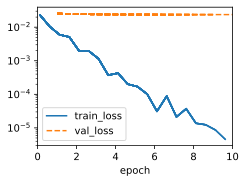

In [ ]:
train_scratch(0)

#### 3.7.3.4. Using Weight Decay

Below, we run with substantial weight decay. Note that the training error increases but the validation error decreases. This is precisely the effect we expect from regularization.

L2 norm of w: 0.0014712829142808914


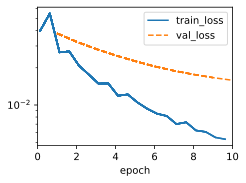

In [ ]:
train_scratch(3)

### 3.7.4. Concise Implementation

Because weight decay is ubiquitous in neural network optimization, the deep learning framework makes it especially convenient, integrating weight decay into the optimization algorithm itself for easy use in combination with any loss function. Moreover, this integration serves a computational benefit, allowing implementation tricks to add weight decay to the algorithm, *without any additional computational overhead*. Since the weight decay portion of the update depends only on the current value of each parameter, the optimizer must touch each parameter once anyway.

Below, we specify the weight decay hyperparameter directly through `weight_decay` when instantiating our optimizer. By default, PyTorch decays both weights and biases simultaneously, but we can configure the optimizer to handle different parameters according to different policies. Here, we only set `weight_decay` for the weights (the `net.weight` parameters), hence the bias (the `net.bias` parameter) will not decay.

In [ ]:
class WeightDecay(d2l.LinearRegression):
    def __init__(self, wd, lr):
        super().__init__(lr)
        self.save_hyperparameters()
        self.wd = wd

    def configure_optimizers(self):
        return torch.optim.SGD([
            {'params': self.net.weight, 'weight_decay': self.wd},
            {'params': self.net.bias}], lr=self.lr)

The plot looks similar to that when we implemented weight decay from scratch. However, this version runs faster and is easier to implement, benefits that will become more pronounced as you address larger problems and this work becomes more routine.

L2 norm of w: 0.014734339900314808


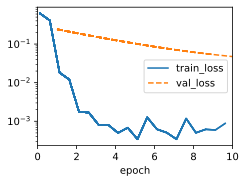

In [ ]:
model = WeightDecay(wd=3, lr=0.01)
model.board.yscale='log'
trainer.fit(model, data)

print('L2 norm of w:', float(l2_penalty(model.get_w_b()[0])))

So far, we have touched upon one notion of what constitutes a simple linear function. However, even for simple nonlinear functions, the situation can be much more complex. To see this, the concept of [reproducing kernel Hilbert space (RKHS)](https://en.wikipedia.org/wiki/Reproducing_kernel_Hilbert_space) allows one to apply tools introduced for linear functions in a nonlinear context. Unfortunately, RKHS-based algorithms tend to scale poorly to large, high-dimensional data. In this book we will often adopt the common heuristic whereby weight decay is applied to all layers of a deep network.

### 3.7.5. Summary

Regularization is a common method for dealing with overfitting. Classical regularization techniques add a penalty term to the loss function (when training) to reduce the complexity of the learned model. One particular choice for keeping the model simple is using an $\ell_2$ penalty. This leads to weight decay in the update steps of the minibatch stochastic gradient descent algorithm. In practice, the weight decay functionality is provided in optimizers from deep learning frameworks. Different sets of parameters can have different update behaviors within the same training loop.

### 3.7.6. Exercises

1. Experiment with the value of $\lambda$ in the estimation problem in this section. Plot training and validation accuracy as a function of $\lambda$. What do you observe?

1. Use a validation set to find the optimal value of $\lambda$. Is it really the optimal value? Does this matter?

1. What would the update equations look like if instead of $\|\mathbf{w}\|^2$ we used $\sum_i |w_i|$ as our penalty of choice ($\ell_1$ regularization)?

1. We know that $\|\mathbf{w}\|^2 = \mathbf{w}^\top \mathbf{w}$. Can you find a similar equation for matrices (see the Frobenius norm in Section 2.3.11)?

1. Review the relationship between training error and generalization error. In addition to weight decay, increased training, and the use of a model of suitable complexity, what other ways might help us deal with overfitting?

1. In Bayesian statistics we use the product of prior and likelihood to arrive at a posterior via $P(w \mid x) \propto P(x \mid w) P(w)$. How can you identify $P(w)$ with regularization?

Q5- 文心：训练误差和泛化误差之间的关系是：训练误差衡量了模型在训练数据上的表现，而泛化误差则是衡量模型在未见过的数据上的表现。一般来说，训练误差会随着模型复杂度的增加而减小，但泛化误差会在某个点之后开始增大，这就是过拟合的情况。

除了权重衰减、增加训练数据和使用合适复杂度的模型之外，处理过拟合的其他方法包括：

1. **早停（Early Stopping）**：在训练过程中监控验证误差，当验证误差不再下降甚至开始上升时，停止训练，这有助于避免模型在训练数据上过度拟合。

1. **数据增强（Data Augmentation）**：通过对训练数据进行变换，如旋转、缩放、剪裁等，可以生成更多的训练样本，有助于提高模型的泛化能力。

1. **特征选择（Feature Selection）**：选择最具代表性的特征，去除对模型学习没有帮助的特征，可以减少过拟合的风险。

1. **集成方法（Ensemble Methods）**：如 Bagging、Boosting 等集成学习方法，通过结合多个模型的预测结果，可以降低过拟合的风险，提高泛化能力。

1. **Dropout**：在训练过程中随机关闭神经元，可以有效地减少神经网络的过拟合。

1. **正则化方法**：除了权重衰减外，还可以使用 L1/L2 正则化、弹性网络等方法来限制模型的复杂度，减少过拟合的风险。

这些方法可以在一定程度上帮助处理过拟合问题，但需要根据具体情况和数据特点进行选择和调整。

文心：
1. **Bagging（自助聚合）**：Bagging 是一种并行集成学习方法，通过随机有放回地从原始训练数据集中采样多个子集，然后使用这些子集分别训练出多个基学习器。最终的预测结果是这些基学习器预测结果的平均值（对于回归问题）或者投票（对于分类问题）。著名的随机森林（Random Forest）算法就是基于 Bagging 的思想。

1. **Boosting（提升）**：Boosting 是一种串行集成学习方法，它通过迭代训练一系列基学习器，每一轮都调整数据分布，使得前一个基学习器预测错误的样本在下一轮中得到更多的关注。著名的算法有 AdaBoost、Gradient Boosting Machine (GBM)、XGBoost 和 LightGBM 等。

1. **弹性网络（Elastic Net）**：是一种结合了 L1 和 L2 正则化的线性回归模型。它的损失函数包括两部分：一部分是传统的线性回归损失函数，另一部分是 L1 和 L2 范数的惩罚项。这种模型综合了 Lasso 回归（L1 正则化）和 Ridge 回归（L2 正则化）的优点，能够在高维数据集中进行特征选择，并且能够处理特征相关性较强的情况。弹性网络在特征数量远远大于样本数量的情况下特别有用。



Q6 - 文心：在贝叶斯统计中，我们使用先验概率 $P(w)$ 和似然函数 $P(x \mid w)$ 的乘积来得到后验概率 $P(w \mid x)$，这通常通过贝叶斯公式表达为：

$$P(w \mid x) = \frac{P(x \mid w) P(w)}{P(x)}$$

由于$P(x)$（证据因子）对于所有 $w$ 都是相同的，因此在比较不同 $w$ 的后验概率时，我们可以忽略它，从而得到：

$$P(w \mid x) \propto P(x \mid w) P(w)$$

这里，符号 $\propto$ 表示“成比例于”。

**先验概率 $P(w)$ 与正则化的关系**

在机器学习和统计建模中，先验概率 $P(w)$ 扮演着正则化的角色。正则化是一种技术，用于减少模型的复杂度或避免过拟合。通过选择合适的先验分布，我们可以对模型的参数 $w$ 施加不同的假设或约束，这些假设或约束实际上起到了正则化的作用。

例子

**L2 正则化**

如果我们选择高斯分布（正态分布）作为先验，即 $P(w) = \mathcal{N}(w; 0, \sigma^2)$，其中 $\sigma^2$ 是方差，那么对数的先验概率可以表示为：

$$\log P(w) = -\frac{1}{2\sigma^2} \sum_i w_i^2 + \text{常数}$$

注意，这里的负号意味着最大化先验概率（或最小化其负对数）等同于最小化 $\sum_i w_i^2$，这正是 L2 正则化的形式。

**L1正则化**

如果我们选择拉普拉斯分布作为先验，即 $P(w) = \text{Laplace}(w; 0, b)$，其中 $b$ 是尺度参数，那么对数的先验概率可以表示为：

$$\log P(w) = -\frac{1}{b} \sum_i |w_i| + \text{常数}$$

同样地，最小化这个先验的负对数等同于最小化 $\sum_i |w_i|$，即 L1 正则化。

因此，通过选择不同的先验分布，我们可以将正则化项自然地嵌入到贝叶斯统计框架中。这种方法不仅提供了正则化的直观解释，还允许我们利用贝叶斯统计的强大工具来估计模型的参数和不确定性。

牧之：在贝叶斯算法中，为什么不同的参数会假设具有不同的分布？这在现实生活中有什么依据吗？

GPT：在贝叶斯统计学中，不同的参数假设具有不同的分布是因为我们通常对参数的先验分布有一定的信念或者先验知识。这种信念可以基于领域专家的经验、历史数据或者其他信息。不同的参数可能具有不同的性质，因此我们可以根据问题的特点选择适当的先验分布。在现实生活中，这种假设可以通过多种方式得到支持。例如，在医学研究中，对于不同药物的有效性可能有不同的信念，这可以反映在贝叶斯模型的先验分布中。在工程领域，对于不同材料的性能特点也可能有不同的先验信念，因此可以使用不同的先验分布来反映这些信念。总之，贝叶斯方法允许我们将先验知识和观测数据进行结合，以得到更加准确的推断结果。

